In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sdf_utils import sap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [2]:
import torch
from sdf_utils import sap
import time
import random
import deep_sdf
from deep_sdf import mesh, metrics, lr_scheduling, plotting, utils, loss, data
import deep_sdf.workspace as ws
import json
import os
import reconstruct
import numpy as np
import matplotlib.pyplot as plt
import networks.sdf_vae as vae
import logging

In [3]:
def get_spec_with_default(specs, key, default):
    try:
        return specs[key]
    except KeyError:
        return default

In [4]:
#experiment_directory = "examples/torus/Run_w_con_loss_one_variable_usual"
experiment_directory = "examples/torus_subgroup"
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
test_split_file = specs["TestSplit"]
train_split_file = specs["TrainSplit"]
data_source_mesh = specs["DataSourceMesh"]
with open(test_split_file, "r") as f:
    test_split = json.load(f)
eval_test_scene_num = get_spec_with_default(specs, "EvalTestSceneNumber", 10)
eval_test_optimization_steps = get_spec_with_default(specs, "EvalTestOptimizationSteps", 1000)
eval_grid_res = get_spec_with_default(specs, "EvalGridResolution", 256)
torus_path = get_spec_with_default(specs, "TorusPath", "/home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/scaled_obj_files")

In [5]:
# 2. Load the filenames of the meshes
with open(os.path.join(experiment_directory, "specs.json"), "r") as f:
    import json
    specs = json.load(f)
# Load all labels from the centralized label.pt file
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]
labels_path = os.path.join(data_source, "labels.pt")

# Load the split file to get filenames
with open(train_split_file, "r") as f:
    valid_filenames = json.load(f)

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    print(f"All labels: {all_labels}")
    
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        print(f"Base name: {base_name}")
        params = {}
        if base_name in all_labels:
            label = all_labels[base_name]
            params["has_bump"] = int(label[0].item())  # bump info at index 0
            params["scale"] = float(label[2].item())   # scale info at index 2
            params["bump_size"] = float(label[3].item())
            params["subgroup"] = int(label[4].item())
            #print(f"Label for {base_name}: {params}")
        else:
            print(f"Warning: No label found for {base_name}")
            params["has_bump"] = 0
            params["scale"] = 0.0
            params["bump_size"] = 0.0    
            params["subgroup"] = 0    
        mesh_params.append(params)

Loading labels from /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/labels.pt
All labels: {'torus_bump_0000': array([0.        , 1.        , 0.77926421, 0.64882943, 1.        ]), 'torus_bump_0001': array([1.        , 1.        , 0.26086957, 0.33779264, 1.        ]), 'torus_bump_0002': array([0.        , 1.        , 0.43812709, 0.54849498, 1.        ]), 'torus_bump_0003': array([1.        , 1.        , 0.03344482, 0.45819398, 1.        ]), 'torus_bump_0004': array([0.        , 1.        , 0.79598662, 0.17056856, 1.        ]), 'torus_bump_0005': array([1.        , 1.        , 0.60200669, 0.74247492, 1.        ]), 'torus_bump_0006': array([0.        , 1.        , 0.86956522, 0.11371237, 1.        ]), 'torus_bump_0007': array([1.        , 1.        , 0.13712375, 0.17391304, 1.        ]), 'torus_bump_0008': array([0.        , 1.        , 0.20401338, 0.75585284, 1.        ]), 'torus_bump_0009': array([1.   

In [6]:
# Extract parameters for visualization
has_bump = np.array([p.get("has_bump", 0) for p in mesh_params])
scales = np.array([p.get("scale", 0.0) for p in mesh_params])
bump_sizes = np.array([p.get("bump_size", 0.0) for p in mesh_params])
subgroups = np.array([p.get("subgroup", 0) for p in mesh_params])

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((has_bump, scales, bump_sizes, subgroups))
factor_names = ["bump", "scale", "bump_size", "subgroup"]

In [7]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [8]:
arch = __import__("networks." + specs["NetworkArch"], fromlist=["Decoder"])
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

#decoder = arch.Decoder(latent_size, **specs["NetworkSpecs"])
decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
#decoder = torch.nn.DataParallel(decoder)

saved_model_state = torch.load(
    os.path.join(
        experiment_directory, ws.model_params_subdir, "latest" + ".pth"
    )
)
saved_model_epoch = saved_model_state["epoch"]

decoder.load_state_dict(saved_model_state["model_state_dict"])
#decoder = decoder.module.cuda()
decoder.eval()

SDFVAE(
  (encoder): DataParallel(
    (module): ResnetPointnet(
      (fc_pos): Linear(in_features=3, out_features=256, bias=True)
      (block_0): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_1): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_2): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_3): ResnetBlockFC(
        

In [9]:
eval_test_time_start = time.time()
test_err_sum = 0.
chamfer_dists = []
chamfer_dists_all = []
test_loss_hists = []
mesh_label_names = []
test_latents = []
sap_scores = []
all_labels = []
all_labels_reg = []
all_labels_group = []
all_latents = []

In [10]:
with open(train_split_file, "r") as f:
    train_split = json.load(f)

In [11]:
#eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, test_split)
eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, train_split)
labels = torch.load(data_source + "/labels.pt")
#eval_test_filenames = random.sample(eval_test_filenames, max(eval_test_scene_num, len(eval_test_filenames)))

In [16]:
for test_fname in eval_test_filenames:
    save_name = os.path.basename(test_fname).split(".npz")[0]
    mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
    test_surface_points = data.get_surface_points(mesh_path)
    test_surface_points = torch.from_numpy(test_surface_points)
    test_surface_points = test_surface_points.unsqueeze(0)
    label = labels.get(save_name)
    all_labels.append(label[0])
    all_labels_reg.append(label[2])
    all_labels_group.append(label[4])
    mesh_label_names.append(save_name)
    path = os.path.join(experiment_directory, "all_unsupervised", ws.tb_logs_test_reconstructions, save_name)
    if not os.path.exists(path):
        os.makedirs(path)
        
    test_fpath = os.path.join(data_source, ws.sdf_samples_subdir, test_fname)
    test_sdf_samples = deep_sdf.data.read_sdf_samples_into_ram(test_fpath)
    test_sdf_samples[0] = test_sdf_samples[0][torch.randperm(test_sdf_samples[0].shape[0])]
    test_sdf_samples[1] = test_sdf_samples[1][torch.randperm(test_sdf_samples[1].shape[0])]
 
    print(f"Creating mesh for {test_fname}...")
    test_latent = None
    start = time.time()
    with torch.no_grad():
        test_mesh, z = mesh.create_mesh(
            decoder, 
            kl_div_loss,
            test_surface_points,
            test_latent, 
            N=eval_grid_res, 
            max_batch=int(2 ** 18), 
            filename=os.path.join(path, f"epoch={saved_model_epoch}"),
            return_trimesh=True,
            return_latent=True
        )
    print(f"Mesh creation for {test_fname} took {time.time()-start} seconds.")

    all_latents.append(z)

    if test_mesh is not None:
        gt_mesh_path = f"{torus_path}/{save_name}.obj"
        cd, cd_all = metrics.compute_metric(gt_mesh=gt_mesh_path, gen_mesh=test_mesh, metric="chamfer")
        chamfer_dists.append(cd)
        chamfer_dists_all.append(cd_all)

        del test_sdf_samples, test_mesh

Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_0505.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_0505.npz took 7.483052492141724 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3796.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3796.npz took 5.28882622718811 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_4084.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bum

In [17]:
# Create a directory to store the metrics
metrics_dir = os.path.join(experiment_directory, "metrics")
os.makedirs(metrics_dir, exist_ok=True)

# Save the aggregated Chamfer distances
chamfer_path = os.path.join(metrics_dir, "chamfer_dists.npy")
np.save(chamfer_path, np.array(chamfer_dists))
print(f"Saved aggregated Chamfer distances to {chamfer_path}")

# Save the detailed point-wise Chamfer distances
chamfer_all_path = os.path.join(metrics_dir, "chamfer_dists_all.npy")
np.save(chamfer_all_path, np.array(chamfer_dists_all, dtype=object))
print(f"Saved detailed Chamfer distances to {chamfer_all_path}")

# Save the mapping between mesh names and their Chamfer distances
mesh_chamfer_mapping = {name: dist for name, dist in zip(mesh_label_names, chamfer_dists)}
with open(os.path.join(metrics_dir, "mesh_chamfer_mapping.json"), 'w') as f:
    json.dump(mesh_chamfer_mapping, f, indent=4)
print(f"Saved mesh to Chamfer distance mapping")

# Save all latents
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.stack([l.detach().cpu().numpy() for l in all_latents], axis=0)
np.save(latents_path, all_latents_array)
print(f"Saved all latents to {latents_path}")

Saved aggregated Chamfer distances to examples/torus_subgroup/metrics/chamfer_dists.npy
Saved detailed Chamfer distances to examples/torus_subgroup/metrics/chamfer_dists_all.npy
Saved mesh to Chamfer distance mapping
Saved all latents to examples/torus_subgroup/metrics/all_latents.npy


In [12]:
metrics_dir = os.path.join(experiment_directory, "metrics")
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.load(latents_path)
print(f"Shape of all latents: {all_latents_array.shape}")

Shape of all latents: (400, 1, 16)


In [13]:
all_latents_array = all_latents_array.squeeze()
X = all_latents_array

In [80]:

# 3.1. PCA
print("Applying PCA...")
pca = PCA(n_components=8)
Y_pca = pca.fit_transform(X)
results["PCA"] = Y_pca
transformed_latents["PCA"] = Y_pca
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# check if the scale is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA

best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions (2 to 4)
for n_neighbors in range(300, 320, 10):  # e.g., 5, 10, 15, 20, 25 neighbors
    for n_components in [8]:
        try:
            # Apply HLLE with current parameter set
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            # Apply ICA to the HLLE result
            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)

            # Compute the correlation for each latent variable with scales
            correlations = []
            for comp in range(n_components):
                corr = np.corrcoef(Y_hlle_ica[:, comp], has_bump)[0, 1]
                correlations.append(corr)
            print(correlations)
            # Find the index of the component with the highest absolute correlation
            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]
            
            # Print the results
            print(f"n_neighbors: {n_neighbors}, n_components: {n_components}, "
                  f"best component correlation: {best_component_corr:.4f}")

            # Update if this parameter set shows a higher absolute correlation than previous sets
            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)
                
        except Exception as e:
            print(f"Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}")

if best_Y_hlle_ica is not None:
    print("\nBest parameter set:")
    print(f"n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}")
    results["HLLE+ICA"] = best_Y_hlle_ica
    transformed_latents["HLLE+ICA"] = best_Y_hlle_ica
else:
    print("No valid HLLE+ICA transformation found.")

Applying PCA...
PCA explained variance ratio: 0.9392
Correlation between distance from origin and scale: 0.3121


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


[0.03812590720759128, 0.0031534040558431637, -0.034164730455174444, -0.015152674266426686, -0.024280100228270478, -0.0078085568492610325, -0.004886892876759057, 0.9202209708827577]
n_neighbors: 300, n_components: 8, best component correlation: 0.9202
[0.030600528119479203, 0.004653711608436363, -0.8981780204102428, -0.0031296853743441313, 0.016665084882775, 0.01999470044894503, -0.012529048331358109, -0.04918309068118217]
n_neighbors: 310, n_components: 8, best component correlation: -0.8982

Best parameter set:
n_neighbors: 300, n_components: 8, best component: 7 best correlation: 0.9202


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [68]:
# 3.3. NMF
print("Applying NMF...")
# NMF requires non-negative values
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min  # Shift data to make all values non-negative
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

# Loop over latent dimensions 2, 3, and 4
for n_components in [3]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        # W is the latent representation: shape (num_samples, n_components)
        W = nmf.fit_transform(X_offset)
        
        # Compute the Pearson correlation for each latent component with the scale
        correlations = []
        for comp in range(n_components):
            corr = np.corrcoef(W[:, comp], has_bump)[0, 1]
            correlations.append(corr)
        
        # Identify the best component correlation (by absolute value)
        best_component_corr = max(correlations, key=abs)
        print(f"n_components: {n_components}, best component correlation: {best_component_corr:.4f}")

        # Update if this parameter set shows a higher absolute correlation than previous sets
        if best_corr_nmf is None or abs(best_component_corr) > best_corr_nmf:
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components
            
    except Exception as e:
        print(f"Failed for n_components: {n_components} due to: {e}")

if best_W_nmf is not None:
    print("\nBest NMF parameter set:")
    print(f"n_components: {best_nmf_params}, best correlation: {best_corr_nmf:.4f}")
    results["NMF"] = best_W_nmf
    transformed_latents["NMF"] = best_W_nmf
else:
    print("No valid NMF transformation found.")

Applying NMF...
n_components: 3, best component correlation: -0.8370

Best NMF parameter set:
n_components: 3, best correlation: -0.8370


In [69]:
# 3.4. Factor Analysis
print("Applying Factor Analysis...")
fa = FactorAnalysis(n_components=3, random_state=42)
Y_fa = fa.fit_transform(X)
results["FA"] = Y_fa
transformed_latents["FA"] = Y_fa

# check if the scale is encoded as distance from the origin
center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_fa = distances
distances_all.append(distances)

Applying Factor Analysis...
Correlation between distance from origin and scale: 0.1593


In [79]:
# only ica
# 3.5. ICA
print("Applying ICA...")
ica = FastICA(n_components=8, random_state=42)
Y_ica = ica.fit_transform(X)
results["ICA"] = Y_ica
transformed_latents["ICA"] = Y_ica

# check if the scale is encoded as distance from the origin
center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_ica = distances
distances_all.append(distances)

Applying ICA...
Correlation between distance from origin and scale: 0.3390


In [61]:
techniques = ["PCA", "HLLE+ICA", "NMF", "ICA"]
labels_dict = {
    'has_bump': has_bump,
    'bump_size': bump_sizes, 
    'subgroup': subgroups,
    'scale': scales
}


PCA: Creating plots for 3 component pairs


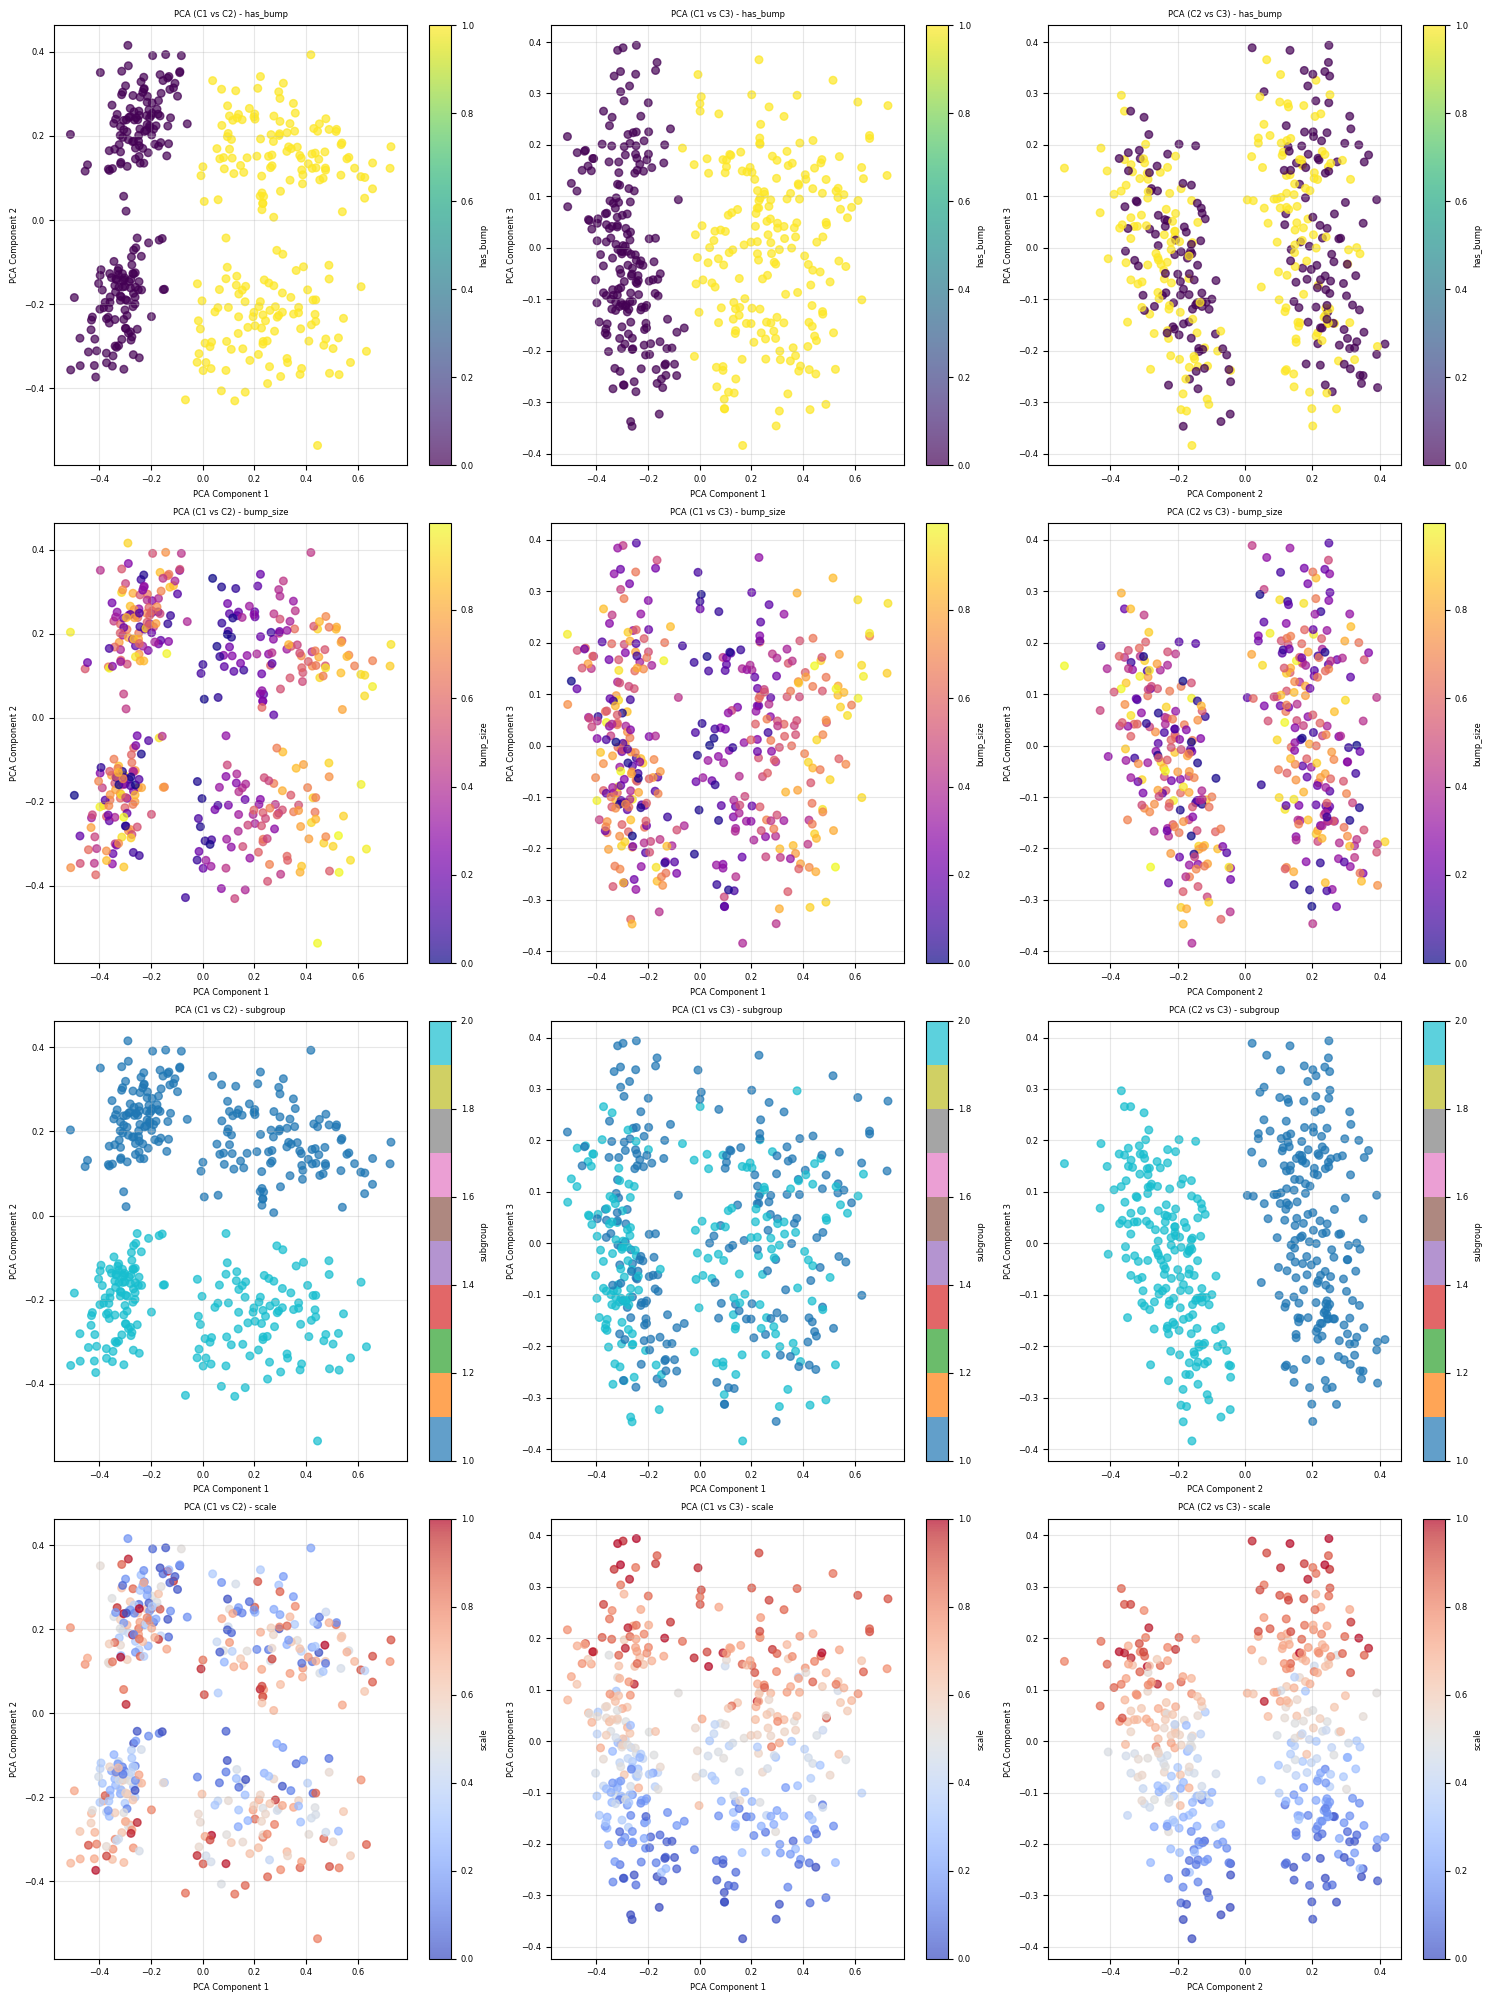


HLLE+ICA: Creating plots for 3 component pairs


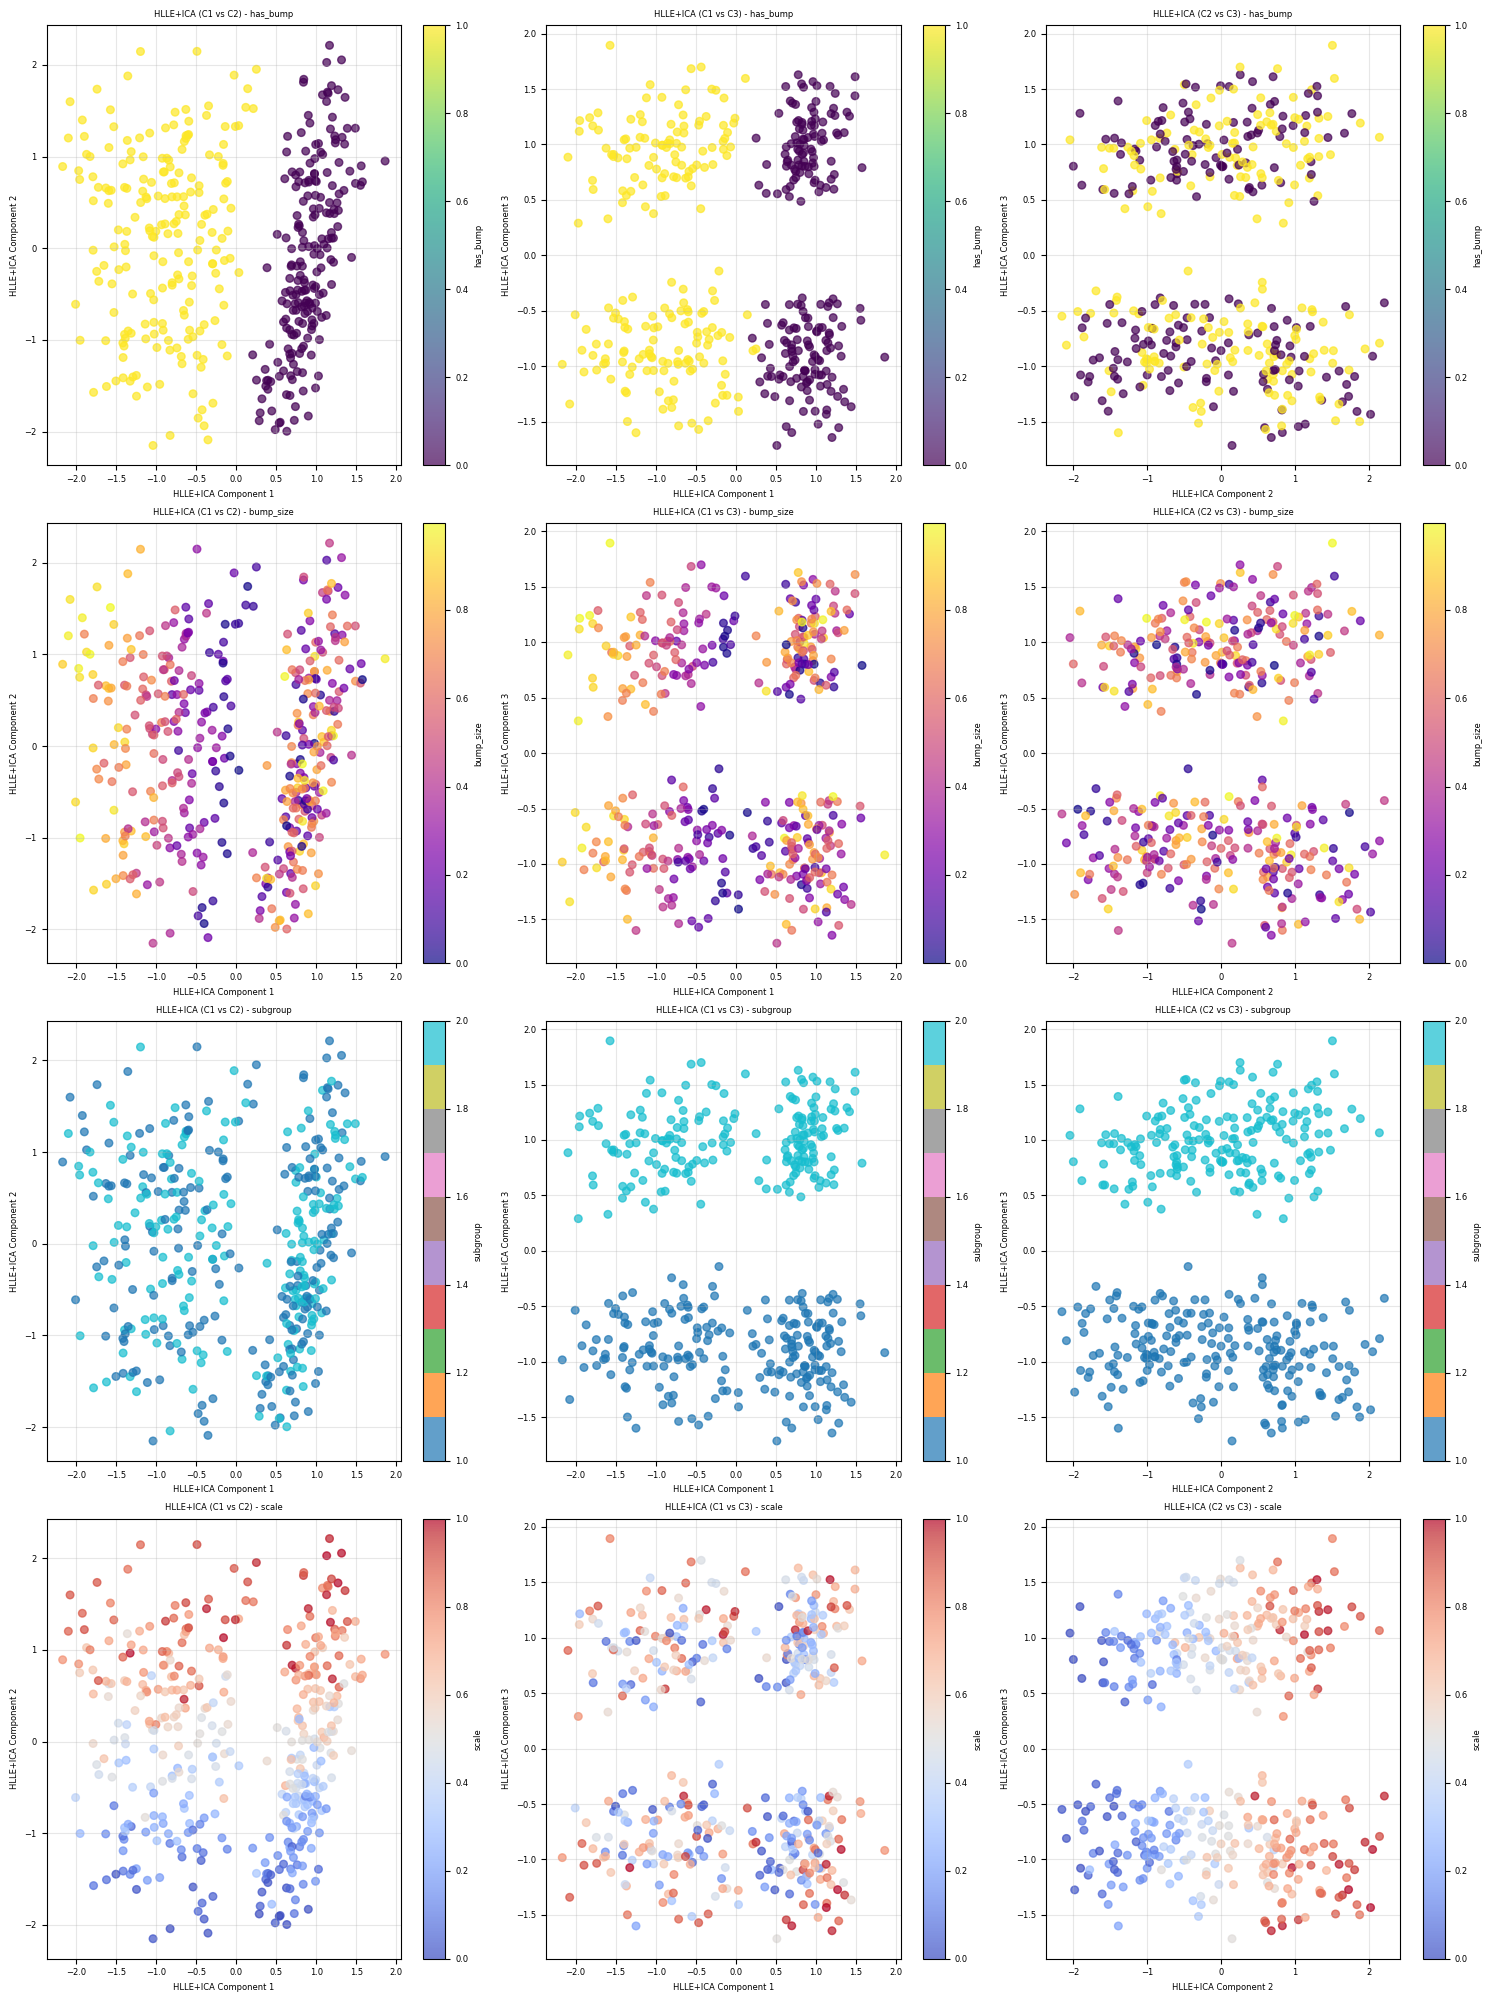


NMF: Creating plots for 3 component pairs


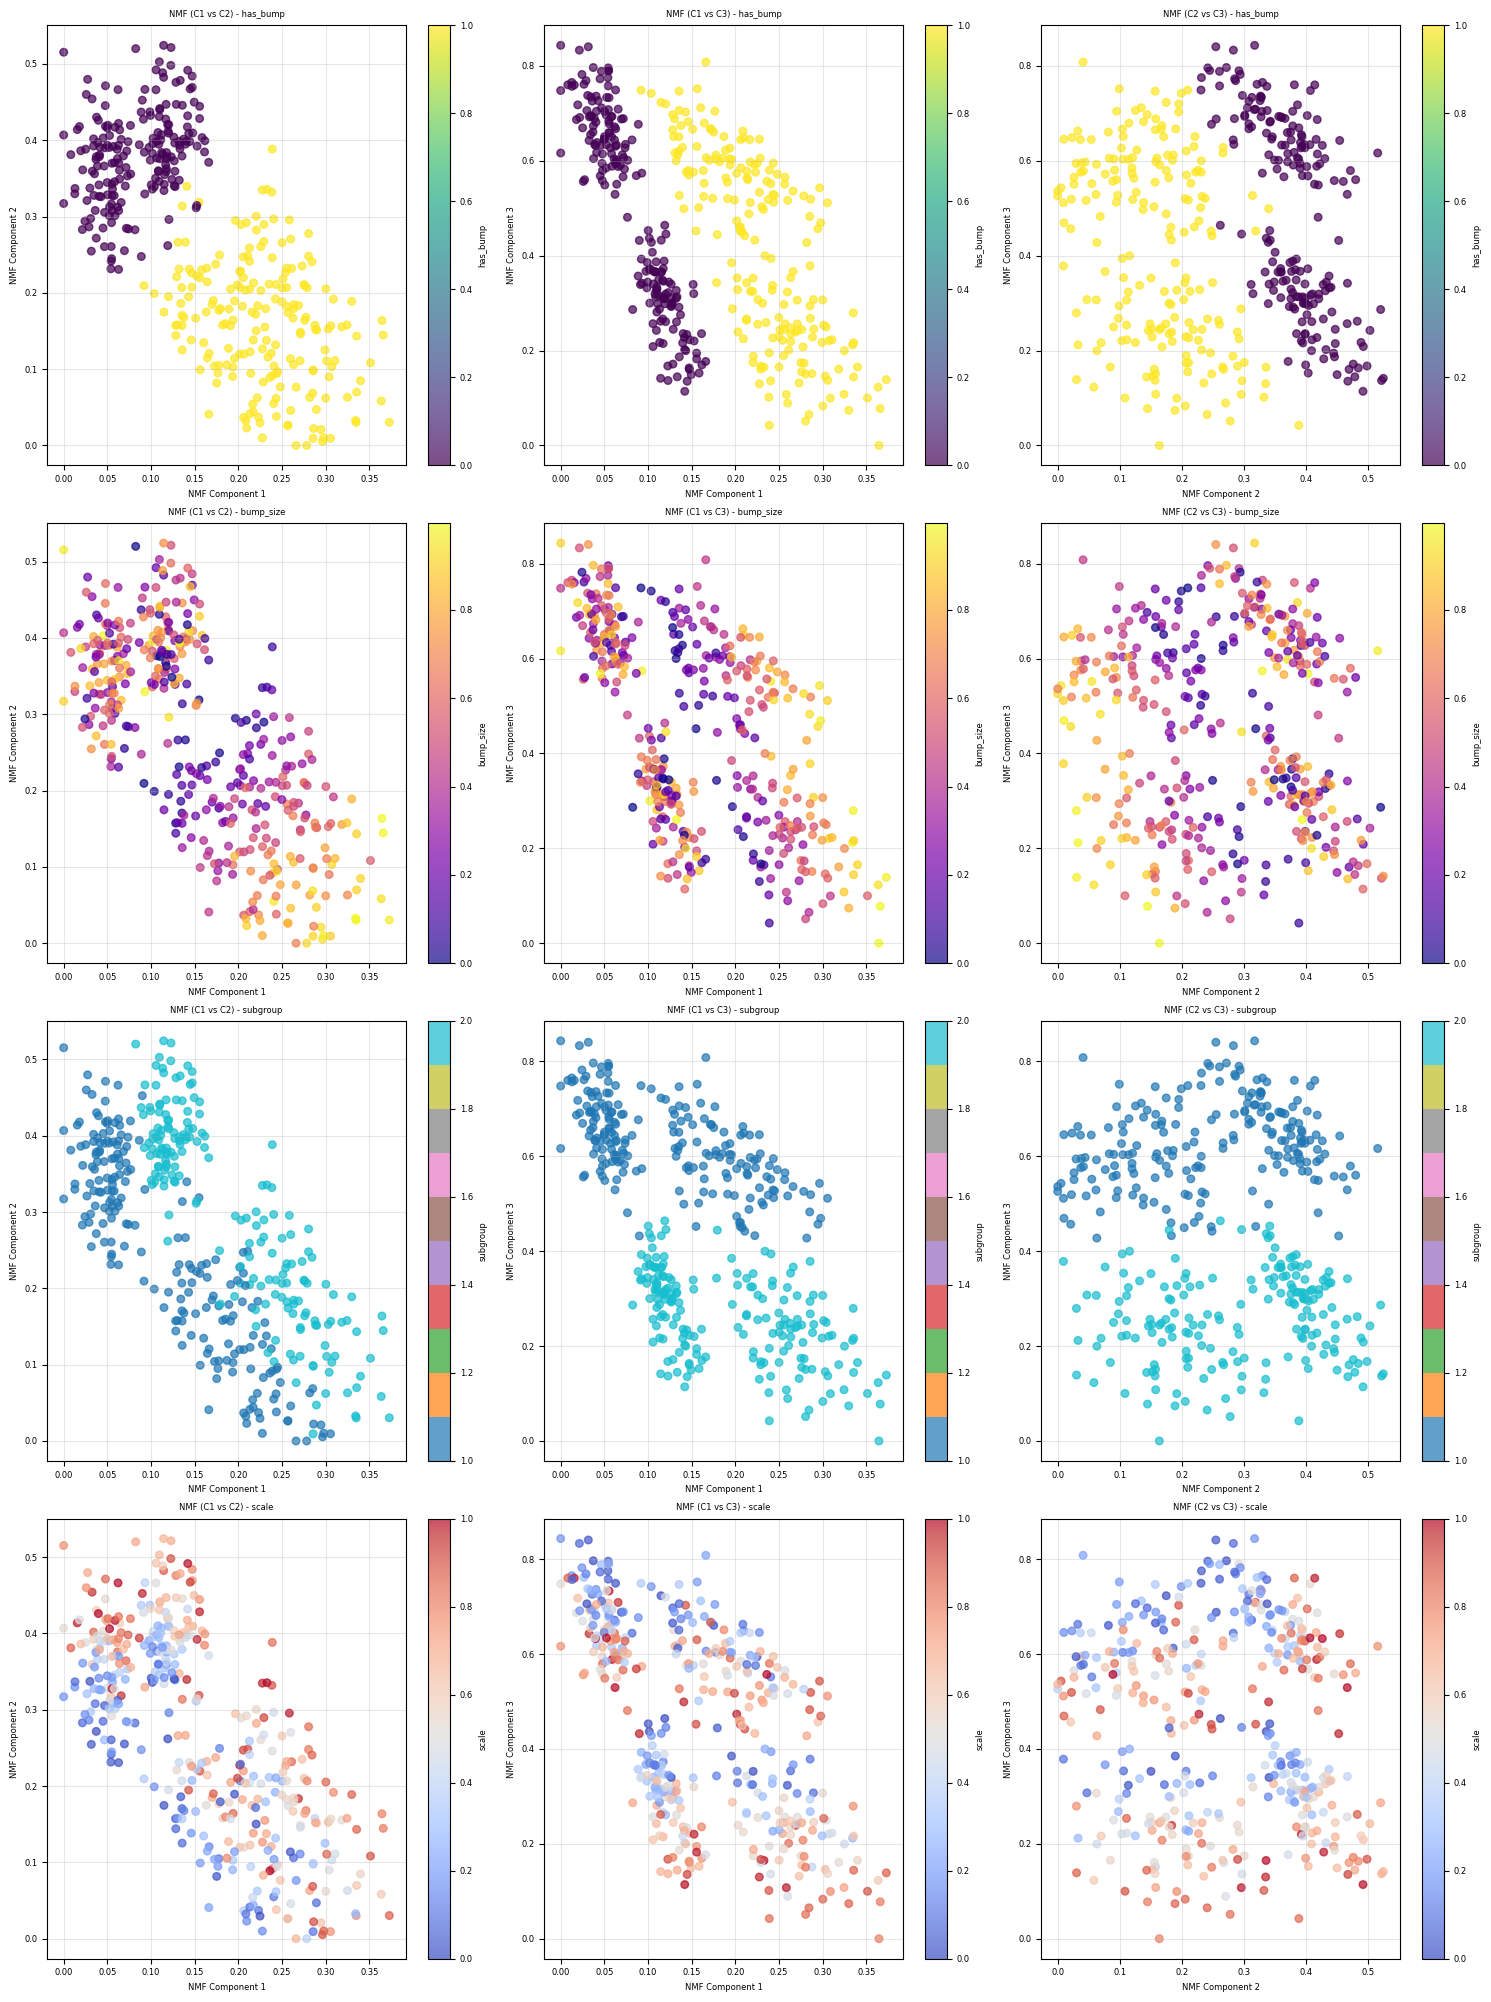


ICA: Creating plots for 3 component pairs


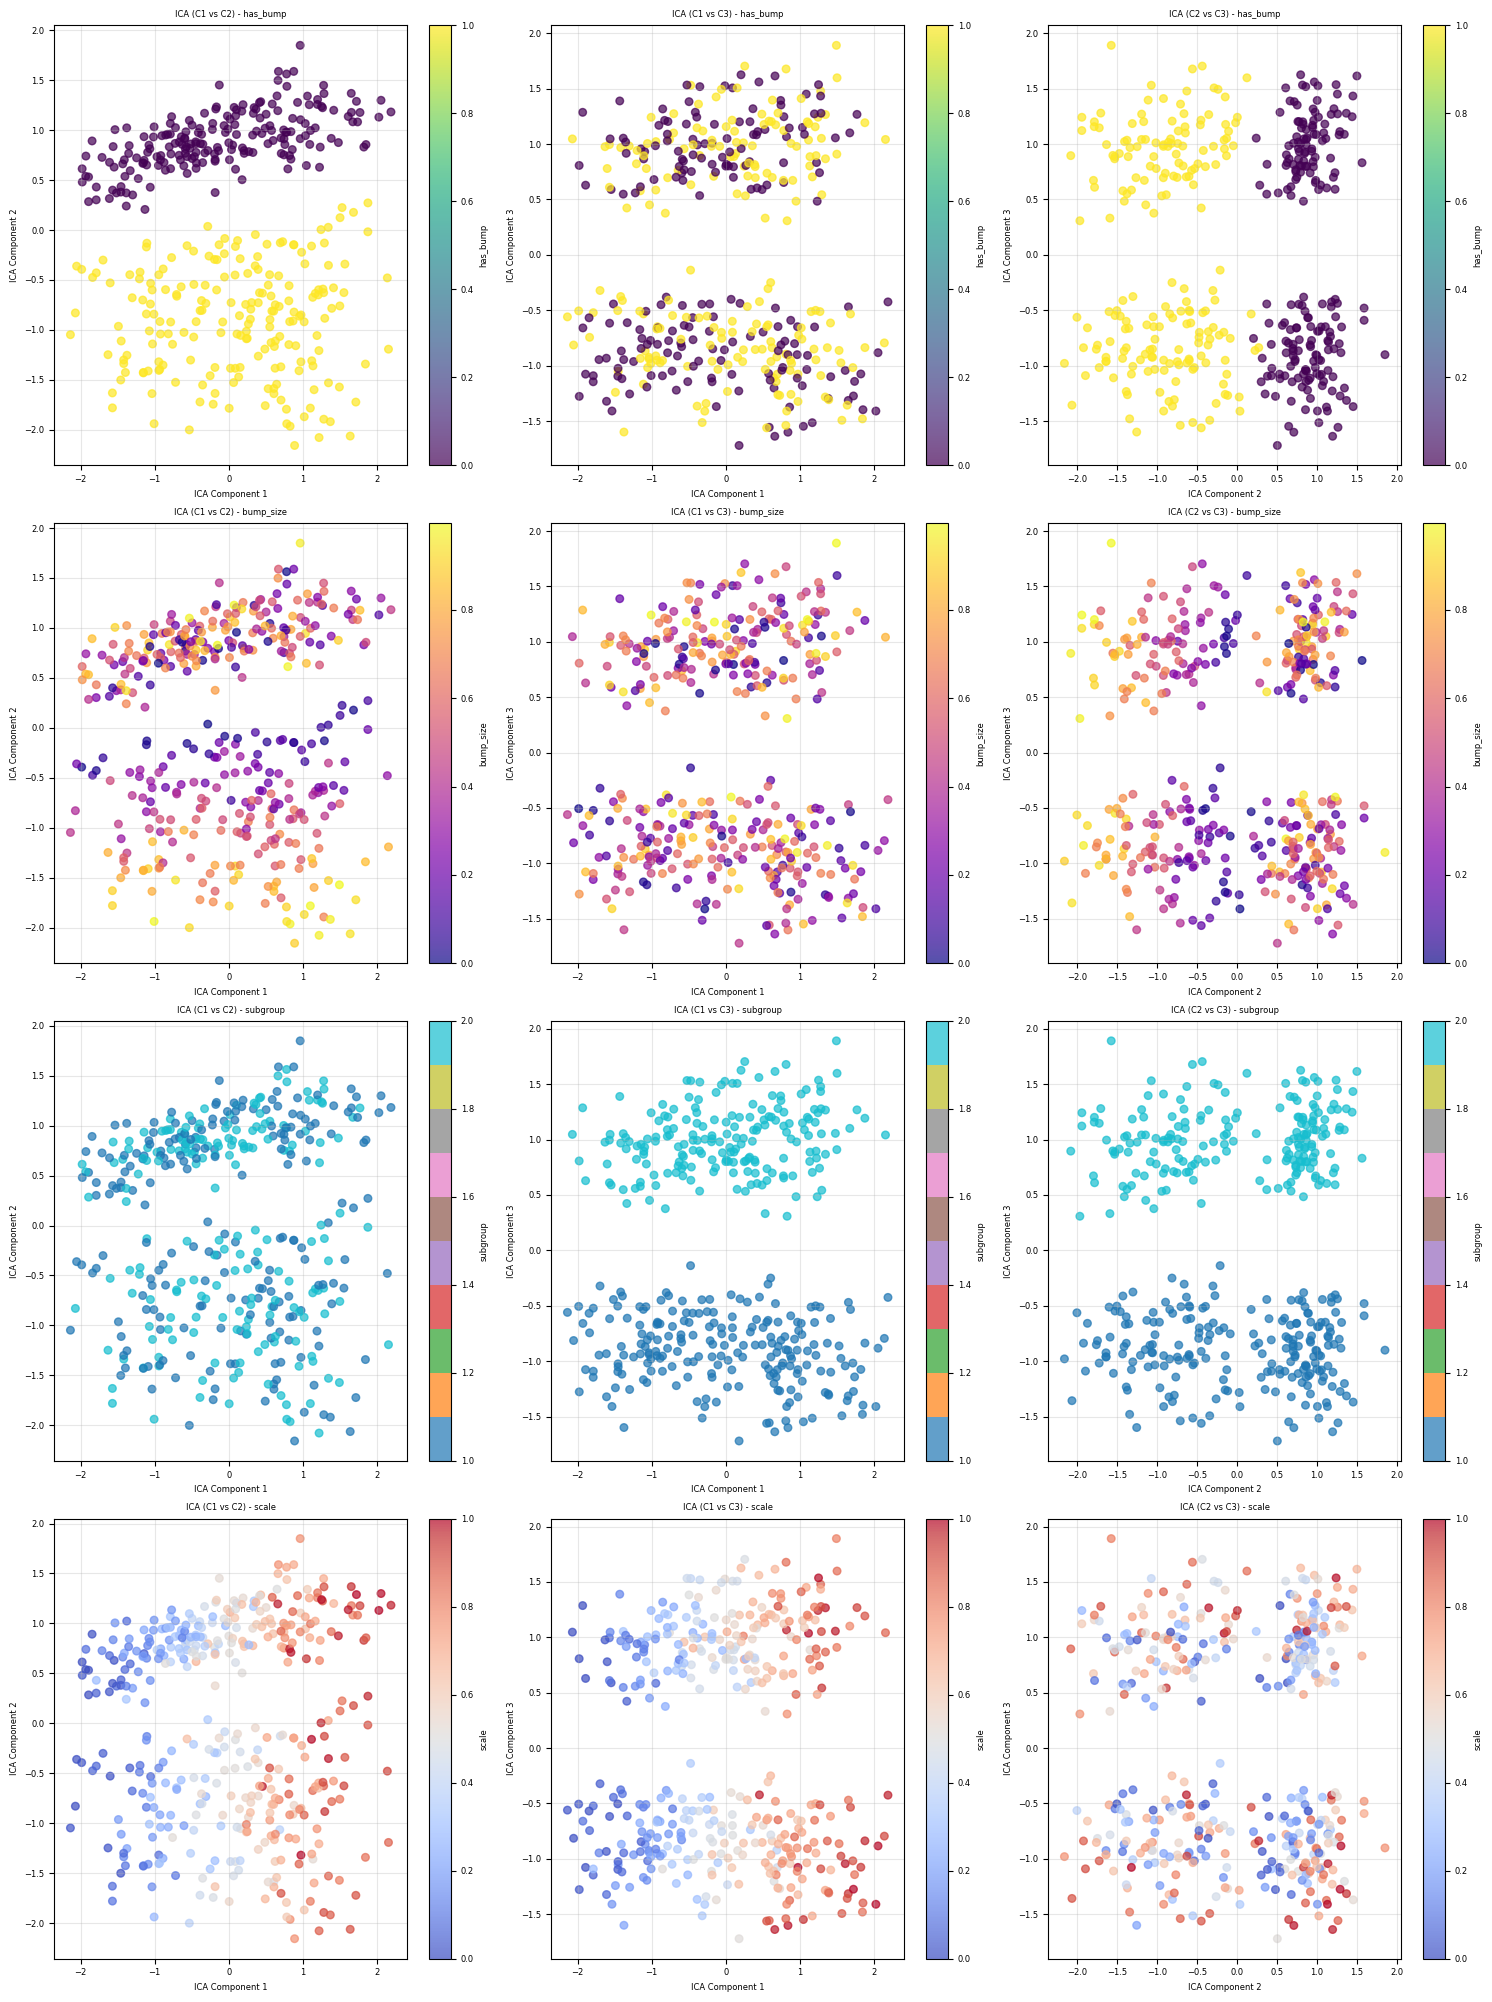

In [71]:
import itertools

# Create comprehensive pairwise component plots

colormaps = {
    'has_bump': 'viridis',
    'bump_size': 'plasma',
    'subgroup': 'tab10',
    'scale': 'coolwarm'
}

# For each technique, create plots for all component pairs
for technique in techniques:
    if technique not in results or np.all(results[technique] == 0):
        print(f"Skipping {technique} - no valid results")
        continue
    
    data = results[technique]
    n_components = data.shape[1]
    
    # Generate all pairs of components
    component_pairs = list(itertools.combinations(range(n_components), 2))
    
    print(f"\n{technique}: Creating plots for {len(component_pairs)} component pairs")
    
    # Create subplots: 4 labels × number of component pairs
    n_pairs = len(component_pairs)
    fig, axes = plt.subplots(4, n_pairs, figsize=(5*n_pairs, 20))
    
    # If only one pair, make axes 2D
    if n_pairs == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot each label type for each component pair
    for label_idx, (label_name, label_data) in enumerate(labels_dict.items()):
        for pair_idx, (comp1, comp2) in enumerate(component_pairs):
            ax = axes[label_idx, pair_idx]
            
            scatter = ax.scatter(data[:, comp1], data[:, comp2], 
                               c=label_data, cmap=colormaps[label_name], 
                               alpha=0.7, s=30)
            
            ax.set_xlabel(f"{technique} Component {comp1+1}")
            ax.set_ylabel(f"{technique} Component {comp2+1}")
            ax.set_title(f"{technique} (C{comp1+1} vs C{comp2+1}) - {label_name}")
            ax.grid(True, alpha=0.3)
            
            # Add colorbar
            plt.colorbar(scatter, ax=ax, label=label_name)
    
    plt.tight_layout()
    plt.savefig(f"{technique}_all_pairs_all_labels.png", dpi=300, bbox_inches='tight')
    plt.show()

In [81]:
# 5. Extended Correlation Analysis - All Components, All Labels
print("\nExtended Correlation Analysis:")
for technique in techniques:
    # Skip if the method failed
    if technique not in results or np.all(results[technique] == 0):
        continue
    
    data = results[technique]
    n_components = data.shape[1]
    
    print(f"\n{technique} Analysis:")
    print("=" * 60)
    
    # Calculate correlations for all components with all labels
    for comp_idx in range(n_components):
        print(f"\nComponent {comp_idx+1}:")
        
        # Calculate correlation with each label type
        bump_corr = np.corrcoef(data[:, comp_idx], has_bump)[0, 1]
        scale_corr = np.corrcoef(data[:, comp_idx], scales)[0, 1]
        bump_size_corr = np.corrcoef(data[:, comp_idx], bump_sizes)[0, 1]
        subgroup_corr = np.corrcoef(data[:, comp_idx], subgroups)[0, 1]
        
        print(f"  Correlation with has_bump:  {bump_corr:.4f}")
        print(f"  Correlation with scale:     {scale_corr:.4f}")
        print(f"  Correlation with bump_size: {bump_size_corr:.4f}")
        print(f"  Correlation with subgroup:  {subgroup_corr:.4f}")
    
    # Find best component for each label type
    print(f"\nBest components for {technique}:")
    
    # For has_bump
    bump_corrs = [abs(np.corrcoef(data[:, i], has_bump)[0, 1]) for i in range(n_components)]
    best_bump_comp = np.argmax(bump_corrs)
    print(f"  has_bump:  Component {best_bump_comp+1} (|corr| = {bump_corrs[best_bump_comp]:.4f})")
    
    # For scale
    scale_corrs = [abs(np.corrcoef(data[:, i], scales)[0, 1]) for i in range(n_components)]
    best_scale_comp = np.argmax(scale_corrs)
    print(f"  scale:     Component {best_scale_comp+1} (|corr| = {scale_corrs[best_scale_comp]:.4f})")
    
    # For bump_size
    bump_size_corrs = [abs(np.corrcoef(data[:, i], bump_sizes)[0, 1]) for i in range(n_components)]
    best_bump_size_comp = np.argmax(bump_size_corrs)
    print(f"  bump_size: Component {best_bump_size_comp+1} (|corr| = {bump_size_corrs[best_bump_size_comp]:.4f})")
    
    # For subgroup
    subgroup_corrs = [abs(np.corrcoef(data[:, i], subgroups)[0, 1]) for i in range(n_components)]
    best_subgroup_comp = np.argmax(subgroup_corrs)
    print(f"  subgroup:  Component {best_subgroup_comp+1} (|corr| = {subgroup_corrs[best_subgroup_comp]:.4f})")


Extended Correlation Analysis:

PCA Analysis:

Component 1:
  Correlation with has_bump:  0.8970
  Correlation with scale:     0.0568
  Correlation with bump_size: 0.1941
  Correlation with subgroup:  -0.1127

Component 2:
  Correlation with has_bump:  -0.1290
  Correlation with scale:     -0.2013
  Correlation with bump_size: -0.0926
  Correlation with subgroup:  -0.9270

Component 3:
  Correlation with has_bump:  0.0121
  Correlation with scale:     0.9073
  Correlation with bump_size: -0.0548
  Correlation with subgroup:  -0.1793

Component 4:
  Correlation with has_bump:  -0.0583
  Correlation with scale:     0.0505
  Correlation with bump_size: 0.0220
  Correlation with subgroup:  0.0245

Component 5:
  Correlation with has_bump:  -0.0369
  Correlation with scale:     -0.1416
  Correlation with bump_size: 0.0179
  Correlation with subgroup:  0.0304

Component 6:
  Correlation with has_bump:  -0.0737
  Correlation with scale:     0.0236
  Correlation with bump_size: 0.1142
  Corre

In [85]:
# Save best ICA components as labels
ica_data = results["ICA"]
best_components = []

# Find best component for each target
for target in [has_bump, scales, subgroups]:
    correlations = [abs(np.corrcoef(ica_data[:, i], target)[0, 1]) for i in range(ica_data.shape[1])]
    best_idx = np.argmax(correlations)
    print(best_idx)
    best_components.append(ica_data[:, best_idx])

# Save as label matrix
ica_labels = np.column_stack(best_components)
np.save(os.path.join(experiment_directory, "ica_best_labels.npy"), ica_labels)
print(f"Saved ICA labels shape: {ica_labels.shape}")

2
7
6
Saved ICA labels shape: (400, 3)


In [89]:
# Analyze ICA labels statistics
ica_labels = np.load(os.path.join(experiment_directory, "ica_best_labels.npy"))

for i in range(ica_labels.shape[1]):
    comp = ica_labels[:, i]
    print(f"Component {i+1}:")
    print(f"  Min: {comp.min():.4f}")
    print(f"  Max: {comp.max():.4f}")
    print(f"  Range: {comp.max() - comp.min():.4f}")

Component 1:
  Min: -1.9615
  Max: 2.1122
  Range: 4.0736
Component 2:
  Min: -2.2004
  Max: 2.5268
  Range: 4.7272
Component 3:
  Min: -1.8923
  Max: 1.6881
  Range: 3.5804


In [91]:
test_labels = np.load(experiment_directory + "/ica_best_labels.npy")
print(f"Test labels shape: {test_labels.shape}")

Test labels shape: (400, 3)


In [92]:
from scipy.stats import kurtosis, skew
from sklearn.metrics import normalized_mutual_info_score

def evaluate_ica_quality(components):
    """Evaluate ICA component quality using statistical measures"""
    metrics = {}
    
    for i in range(components.shape[1]):
        comp = components[:, i]
        
        # Kurtosis (departure from Gaussianity)
        kurt = kurtosis(comp)
        
        # Skewness (asymmetry)
        skewness = skew(comp)
        
        # Negentropy approximation (measure of non-Gaussianity)
        # Using tanh approximation
        negentropy = np.mean(np.tanh(comp)**2) - (np.mean(np.tanh(comp)))**2
        
        metrics[f'component_{i}'] = {
            'kurtosis': kurt,
            'skewness': skewness,
            'negentropy': negentropy,
            'variance': np.var(comp)
        }
    
    return metrics

# Usage
for technique in techniques:
    if technique in results and not np.all(results[technique] == 0):
        quality = evaluate_ica_quality(results[technique])
        print(f"\n{technique} Quality Metrics:")
        for comp, metrics in quality.items():
            print(f"{comp}: Kurt={metrics['kurtosis']:.3f}, "
                  f"Skew={metrics['skewness']:.3f}, "
                  f"Negent={metrics['negentropy']:.3f}")


PCA Quality Metrics:
component_0: Kurt=-1.199, Skew=0.339, Negent=0.087
component_1: Kurt=-1.431, Skew=-0.108, Negent=0.051
component_2: Kurt=-0.743, Skew=0.067, Negent=0.027
component_3: Kurt=-0.343, Skew=0.009, Negent=0.016
component_4: Kurt=0.406, Skew=-0.182, Negent=0.011
component_5: Kurt=0.059, Skew=-0.138, Negent=0.011
component_6: Kurt=-0.180, Skew=0.126, Negent=0.009
component_7: Kurt=0.047, Skew=-0.073, Negent=0.007

HLLE+ICA Quality Metrics:
component_0: Kurt=0.299, Skew=0.220, Negent=0.375
component_1: Kurt=0.913, Skew=0.101, Negent=0.365
component_2: Kurt=-0.366, Skew=-0.163, Negent=0.417
component_3: Kurt=-0.208, Skew=0.099, Negent=0.408
component_4: Kurt=-0.249, Skew=-0.162, Negent=0.398
component_5: Kurt=-0.151, Skew=-0.058, Negent=0.390
component_6: Kurt=-1.392, Skew=0.120, Negent=0.497
component_7: Kurt=-1.397, Skew=0.204, Negent=0.498

NMF Quality Metrics:
component_0: Kurt=-0.903, Skew=0.290, Negent=0.007
component_1: Kurt=-1.042, Skew=-0.207, Negent=0.015
componen

In [22]:
import numpy as np
from sklearn import tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import minmax_scale

def get_bin_index(x, nb_bins):
    """Discretize input variable"""
    bins = np.linspace(0, 1, nb_bins + 1)
    return np.digitize(x, bins[:-1], right=False).astype(int)

def calculate_sap_for_factor(factors, codes, continuous_factors=True, regression=True, nb_bins=10):
    """
    Calculate SAP for a single factor using the implementation from test_two_supervised
    """
    # Reshape inputs if needed
    if len(factors.shape) == 1:
        factors = factors.reshape(-1, 1)
    
    # Count dimensions
    nb_factors = factors.shape[1]
    nb_codes = codes.shape[1]
    
    # Calculate SAP matrices and scores
    if regression:
        assert continuous_factors, "Cannot perform SAP regression with discrete factors."
        s_matrix = np.zeros((nb_factors, nb_codes))
        
        # Calculate R2 score matrix
        for f in range(nb_factors):
            for c in range(nb_codes):
                regr = LinearRegression()
                regr.fit(codes[:, c].reshape(-1, 1), factors[:, f].reshape(-1, 1))
                y_pred = regr.predict(codes[:, c].reshape(-1, 1))
                r2 = r2_score(factors[:, f], y_pred)
                s_matrix[f, c] = max(0, r2)
        
    else:
        # For classification
        if continuous_factors:
            factors_norm = minmax_scale(factors.copy())
            factors_quantized = np.zeros_like(factors_norm, dtype=int)
            for f in range(factors_norm.shape[1]):
                factors_quantized[:, f] = get_bin_index(factors_norm[:, f], nb_bins)
            factors = factors_quantized
        
        codes_norm = minmax_scale(codes.copy())
        s_matrix = np.zeros((nb_factors, nb_codes))
        
        for f in range(nb_factors):
            for c in range(nb_codes):
                best_score, best_sp = 0, 1
                for sp in range(1, 10):
                    try:
                        clf = tree.DecisionTreeClassifier(max_depth=sp, random_state=42)
                        scores = cross_val_score(
                            clf, 
                            codes_norm[:, c].reshape(-1, 1), 
                            factors[:, f].reshape(-1), 
                            cv=5,
                            scoring='accuracy'
                        )
                        score = scores.mean()
                        if score > best_score:
                            best_score = score
                            best_sp = sp
                    except:
                        continue
                
                try:
                    clf = tree.DecisionTreeClassifier(max_depth=best_sp, random_state=42)
                    clf.fit(codes_norm[:, c].reshape(-1, 1), factors[:, f].reshape(-1))
                    y_pred = clf.predict(codes_norm[:, c].reshape(-1, 1))
                    s_matrix[f, c] = accuracy_score(factors[:, f], y_pred)
                except:
                    s_matrix[f, c] = 0.0
    
    # Compute the gap for all factors
    sum_gap = 0
    for f in range(nb_factors):
        s_f = np.sort(s_matrix[f, :])
        if len(s_f) >= 2:
            gap = s_f[-1] - s_f[-2]
        else:
            gap = s_f[-1] if len(s_f) > 0 else 0
        sum_gap += gap
    
    # Compute mean gap
    sap_score = sum_gap / nb_factors if nb_factors > 0 else 0
    
    return sap_score

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((has_bump, scales, bump_sizes, subgroups))
factor_names = ["bump", "scale", "bump_size", "subgroup"]

print("Calculating SAP scores for 16D latent variables:")
print(f"Latent array shape: {all_latents_array.shape}")
print(f"Ground truth factors shape: {ground_truth_factors.shape}")

sap_scores = {}

# Calculate SAP for each factor individually
for i, factor_name in enumerate(factor_names):
    factor_data = ground_truth_factors[:, i].reshape(-1, 1)
    
    print(f"\n{factor_name}:")
    print(f"  Factor shape: {factor_data.shape}")
    print(f"  Unique values: {len(np.unique(factor_data))}")
    
    # Determine method based on factor type
    if factor_name in ['scale', 'bump_size']:
        # Use regression for continuous values
        sap_score = calculate_sap_for_factor(
            factors=factor_data,
            codes=all_latents_array,
            continuous_factors=True,
            regression=True
        )
        method = 'regression'
    else:
        # Use classification for discrete values (bump, subgroup)
        sap_score = calculate_sap_for_factor(
            factors=factor_data,
            codes=all_latents_array,
            continuous_factors=False,
            regression=False
        )
        method = 'classification'
    
    sap_scores[factor_name] = sap_score
    print(f"  SAP Score ({method}): {sap_score:.4f}")

# Print final summary
print(f"\n{'='*50}")
print("FINAL SAP SCORES FOR 16D LATENT VARIABLES")
print(f"{'='*50}")
for factor_name, score in sap_scores.items():
    print(f"{factor_name}: {score:.4f}")
print(f"{'='*50}")

Calculating SAP scores for 16D latent variables:
Latent array shape: (400, 16)
Ground truth factors shape: (400, 4)

bump:
  Factor shape: (400, 1)
  Unique values: 2
  SAP Score (classification): 0.0275

scale:
  Factor shape: (400, 1)
  Unique values: 221
  SAP Score (regression): 0.1367

bump_size:
  Factor shape: (400, 1)
  Unique values: 215
  SAP Score (regression): 0.0005

subgroup:
  Factor shape: (400, 1)
  Unique values: 2
  SAP Score (classification): 0.0375

FINAL SAP SCORES FOR 16D LATENT VARIABLES
bump: 0.0275
scale: 0.1367
bump_size: 0.0005
subgroup: 0.0375


In [23]:
# Calculate SAP scores for dimensionality reduction methods
print(f"\n{'='*60}")
print("CALCULATING SAP SCORES FOR DIMENSIONALITY REDUCTION METHODS")
print(f"{'='*60}")

# Dictionary to store all SAP results
all_method_sap_scores = {
    'Original_16D_Latent': sap_scores.copy()  # Store the original results
}

# Dimensionality reduction methods to evaluate
dr_methods = {
    'PCA': results["PCA"],
    'ICA': results["ICA"], 
    'HLLE+ICA': results["HLLE+ICA"]
}

# Calculate SAP for each dimensionality reduction method
for method_name, components in dr_methods.items():
    if np.all(components == 0):
        print(f"Skipping {method_name} - no valid results")
        continue
    
    print(f"\nCalculating SAP scores for {method_name}:")
    print(f"Components shape: {components.shape}")
    
    method_sap_scores = {}
    
    # Calculate SAP for each factor
    for i, factor_name in enumerate(factor_names):
        factor_data = ground_truth_factors[:, i].reshape(-1, 1)
        
        print(f"  {factor_name}: ", end="")
        
        # Determine method based on factor type
        if factor_name in ['scale', 'bump_size']:
            # Use regression for continuous values
            sap_score = calculate_sap_for_factor(
                factors=factor_data,
                codes=components,
                continuous_factors=True,
                regression=True
            )
            method_type = 'regression'
        else:
            # Use classification for discrete values
            sap_score = calculate_sap_for_factor(
                factors=factor_data,
                codes=components,
                continuous_factors=False,
                regression=False
            )
            method_type = 'classification'
        
        method_sap_scores[factor_name] = sap_score
        print(f"{sap_score:.4f} ({method_type})")
    
    all_method_sap_scores[method_name] = method_sap_scores

# Print comparison table
print(f"\n{'='*70}")
print("SAP SCORES COMPARISON TABLE")
print(f"{'='*70}")

# Header
header = f"{'Method':<20}"
for factor_name in factor_names:
    header += f"{factor_name:<12}"
print(header)
print("-" * 70)

# Data rows
for method_name, scores in all_method_sap_scores.items():
    row = f"{method_name:<20}"
    for factor_name in factor_names:
        score = scores[factor_name]
        row += f"{score:.4f}{'':<8}"
    print(row)

print("-" * 70)

# Calculate and print average SAP scores for each method
print(f"\nAVERAGE SAP SCORES:")
for method_name, scores in all_method_sap_scores.items():
    avg_score = np.mean(list(scores.values()))
    print(f"{method_name}: {avg_score:.4f}")


CALCULATING SAP SCORES FOR DIMENSIONALITY REDUCTION METHODS

Calculating SAP scores for PCA:
Components shape: (400, 16)
  bump: 0.2675 (classification)
  scale: 0.7827 (regression)
  bump_size: 0.0108 (regression)
  subgroup: 0.2600 (classification)

Calculating SAP scores for ICA:
Components shape: (400, 16)
  bump: 0.2325 (classification)
  scale: 0.2058 (regression)
  bump_size: 0.0004 (regression)
  subgroup: 0.2875 (classification)

Calculating SAP scores for HLLE+ICA:
Components shape: (400, 16)
  bump: 0.2250 (classification)
  scale: 0.0484 (regression)
  bump_size: 0.0093 (regression)
  subgroup: 0.3275 (classification)

SAP SCORES COMPARISON TABLE
Method              bump        scale       bump_size   subgroup    
----------------------------------------------------------------------
Original_16D_Latent 0.0275        0.1367        0.0005        0.0375        
PCA                 0.2675        0.7827        0.0108        0.2600        
ICA                 0.2325        0.20

In [31]:
# Check explained variance for different numbers of components
from sklearn.decomposition import PCA

# Fit PCA with all possible components
pca_full = PCA(n_components=min(all_latents_array.shape))
pca_full.fit(all_latents_array)

# Print explained variance ratios
print("Explained Variance by Number of Components:")
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
for i in range(min(16, len(cumulative_variance))):
    print(f"{i+1} components: {cumulative_variance[i]:.4f} ({pca_full.explained_variance_ratio_[i]:.4f} individual)")

# Check if 4 components capture enough variance
if len(cumulative_variance) >= 4:
    print(f"\n4 components capture {cumulative_variance[3]:.2%} of total variance")
if len(cumulative_variance) >= 16:
    print(f"16 components capture {cumulative_variance[15]:.2%} of total variance")

# Calculate reconstruction error for different numbers of components
reconstruction_errors = []
component_counts = [2, 4, 8, 12, 16]

for n_comp in component_counts:
    if n_comp <= all_latents_array.shape[1]:
        # Fit PCA
        pca = PCA(n_components=n_comp)
        transformed = pca.fit_transform(all_latents_array)
        reconstructed = pca.inverse_transform(transformed)
        
        # Calculate reconstruction error
        mse = np.mean((all_latents_array - reconstructed) ** 2)
        reconstruction_errors.append(mse)
        print(f"{n_comp} components - Reconstruction MSE: {mse:.6f}")

# Recommendation based on variance threshold
variance_threshold = 0.95  # 95% of variance
recommended_components = np.argmax(cumulative_variance >= variance_threshold) + 1
print(f"\nRecommended components for {variance_threshold:.0%} variance: {recommended_components}")

Explained Variance by Number of Components:
1 components: 0.3907 (0.3907 individual)
2 components: 0.6055 (0.2148 individual)
3 components: 0.7169 (0.1114 individual)
4 components: 0.7839 (0.0671 individual)
5 components: 0.8301 (0.0461 individual)
6 components: 0.8744 (0.0444 individual)
7 components: 0.9117 (0.0372 individual)
8 components: 0.9392 (0.0275 individual)
9 components: 0.9587 (0.0195 individual)
10 components: 0.9711 (0.0124 individual)
11 components: 0.9829 (0.0118 individual)
12 components: 0.9911 (0.0082 individual)
13 components: 0.9953 (0.0041 individual)
14 components: 0.9986 (0.0033 individual)
15 components: 1.0000 (0.0014 individual)
16 components: 1.0000 (0.0000 individual)

4 components capture 78.39% of total variance
16 components capture 100.00% of total variance
2 components - Reconstruction MSE: 0.006138
4 components - Reconstruction MSE: 0.003362
8 components - Reconstruction MSE: 0.000946
12 components - Reconstruction MSE: 0.000138
16 components - Recon

In [28]:
# Use proper ICA reconstruction
from sklearn.decomposition import FastICA

def proper_ica_analysis(data, max_components=None):
    if max_components is None:
        max_components = min(data.shape)
    
    results = {}
    
    for n_comp in range(2, min(max_components + 1, data.shape[1] + 1)):
        try:
            # Fit ICA
            ica = FastICA(n_components=n_comp, random_state=42, max_iter=2000, tol=1e-6)
            sources = ica.fit_transform(data)
            
            # Proper reconstruction: X = A * S + mean
            # where A is mixing matrix (inverse of components for whitened data)
            mixing_matrix = ica.mixing_  # This is the proper mixing matrix
            reconstructed = sources @ mixing_matrix.T + ica.mean_
            
            # Calculate error
            mse = np.mean((data - reconstructed) ** 2)
            
            # Verify reconstruction makes sense
            reconstruction_error_per_sample = np.mean((data - reconstructed) ** 2, axis=1)
            
            results[n_comp] = {
                'mse': mse,
                'converged': ica.n_iter_ < ica.max_iter,
                'reconstruction_range': [reconstructed.min(), reconstructed.max()],
                'max_sample_error': reconstruction_error_per_sample.max()
            }
            
            print(f"{n_comp}D: MSE={mse:.6f}, Converged={ica.n_iter_ < ica.max_iter}")
            
        except Exception as e:
            print(f"{n_comp}D failed: {e}")
            
    return results

# Run proper analysis
print("PROPER ICA RECONSTRUCTION ANALYSIS:")
ica_results = proper_ica_analysis(all_latents_array, max_components=16)

PROPER ICA RECONSTRUCTION ANALYSIS:
2D: MSE=0.006138, Converged=True
3D: MSE=0.004405, Converged=True
4D: MSE=0.003362, Converged=True
5D: MSE=0.002644, Converged=True
6D: MSE=0.001954, Converged=True


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


7D: MSE=0.001374, Converged=False
8D: MSE=0.000946, Converged=True


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


9D: MSE=0.000642, Converged=False


...

/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


14D: MSE=0.000022, Converged=False


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


15D: MSE=0.000000, Converged=False
16D: MSE=0.000000, Converged=False


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


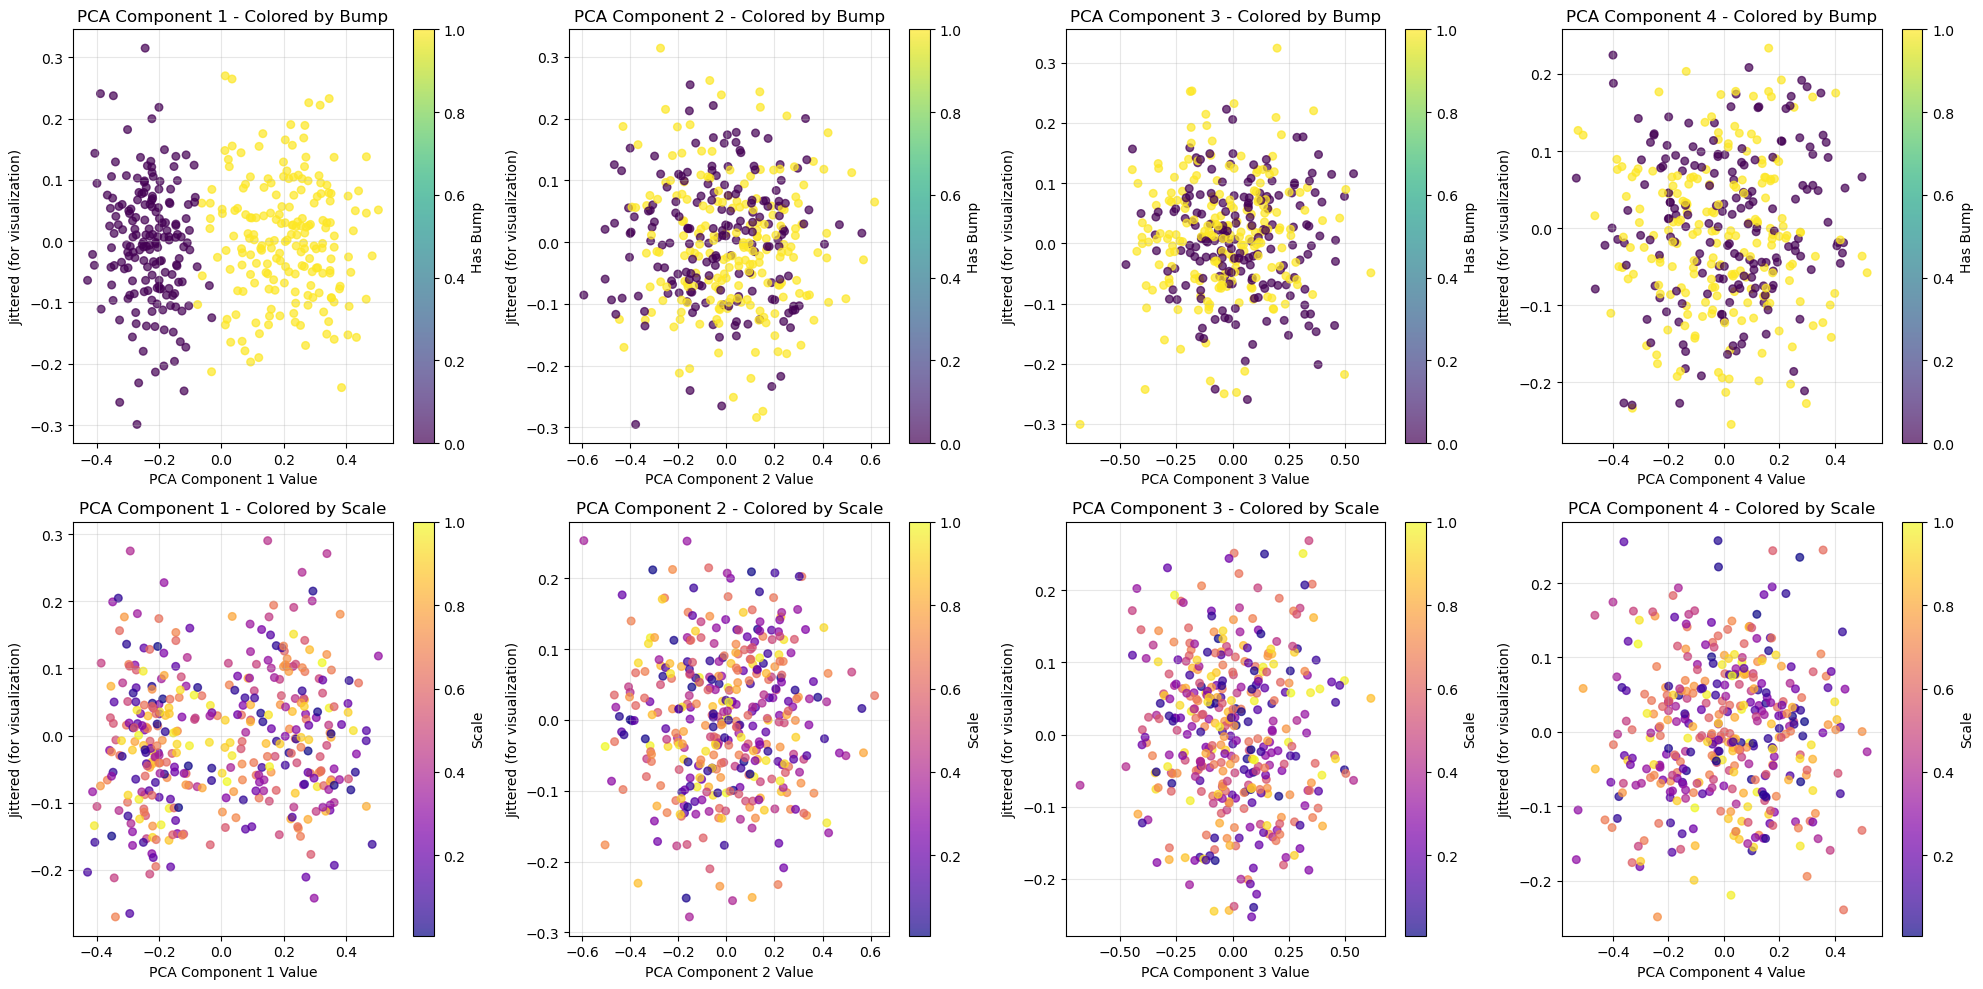

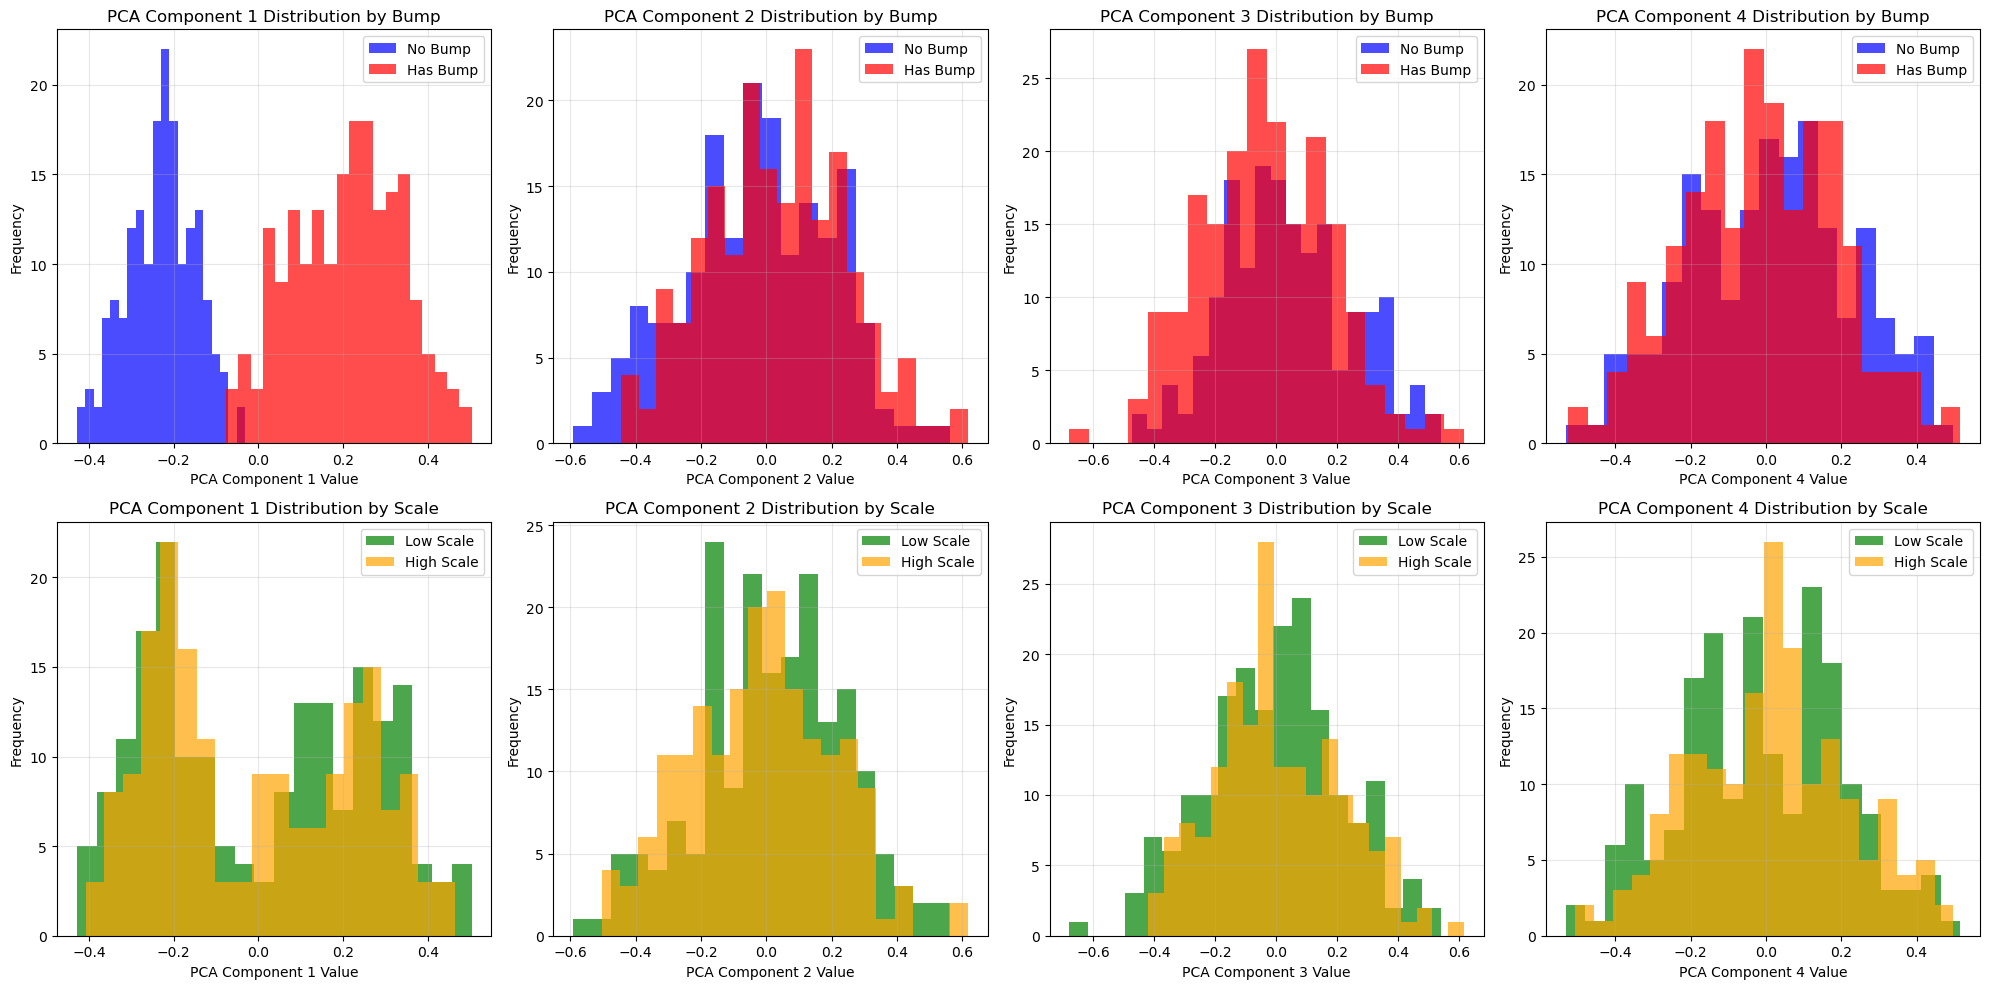


Detailed PCA Correlation Analysis:
PCA Component 1:
  Correlation with bump: 0.8973
  Correlation with scale: -0.0074
PCA Component 2:
  Correlation with bump: 0.1444
  Correlation with scale: -0.0395
PCA Component 3:
  Correlation with bump: -0.1751
  Correlation with scale: 0.0110
PCA Component 4:
  Correlation with bump: -0.0588
  Correlation with scale: -0.0105


In [ ]:
# Plot all 4 PCA components for bump and scale
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Get PCA results
pca_results = results["PCA"]

# Top row: All 4 components colored by bump
for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[0, i].scatter(pca_results[:, i], jittered_y, c=has_bump, 
                                cmap='viridis', alpha=0.7, s=30)
    axes[0, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[0, i].set_ylabel("Jittered (for visualization)")
    axes[0, i].set_title(f"PCA Component {i+1} - Colored by Bump")
    axes[0, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, i], label="Has Bump")

# Bottom row: All 4 components colored by scale
for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[1, i].scatter(pca_results[:, i], jittered_y, c=scales, 
                                cmap='plasma', alpha=0.7, s=30)
    axes[1, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[1, i].set_ylabel("Jittered (for visualization)")
    axes[1, i].set_title(f"PCA Component {i+1} - Colored by Scale")
    axes[1, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, i], label="Scale")

plt.tight_layout()
plt.savefig("pca_all_components_vs_labels.png", dpi=300, bbox_inches='tight')
plt.show()

# Also create histogram distributions for all 4 PCA components
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

bump_mask = has_bump == 1
no_bump_mask = has_bump == 0

# Top row: Component distributions by bump
for i in range(4):
    component = pca_results[:, i]
    axes[0, i].hist(component[no_bump_mask], alpha=0.7, label='No Bump', 
                   bins=20, color='blue')
    axes[0, i].hist(component[bump_mask], alpha=0.7, label='Has Bump', 
                   bins=20, color='red')
    axes[0, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[0, i].set_ylabel("Frequency")
    axes[0, i].set_title(f"PCA Component {i+1} Distribution by Bump")
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Bottom row: Component distributions by scale (split into high/low scale)
scale_median = np.median(scales)
high_scale_mask = scales > scale_median
low_scale_mask = scales <= scale_median

for i in range(4):
    component = pca_results[:, i]
    axes[1, i].hist(component[low_scale_mask], alpha=0.7, label='Low Scale', 
                   bins=20, color='green')
    axes[1, i].hist(component[high_scale_mask], alpha=0.7, label='High Scale', 
                   bins=20, color='orange')
    axes[1, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[1, i].set_ylabel("Frequency")
    axes[1, i].set_title(f"PCA Component {i+1} Distribution by Scale")
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_all_components_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

# Print correlation analysis for all 4 PCA components
print("\nDetailed PCA Correlation Analysis:")
for i in range(4):
    bump_corr = np.corrcoef(pca_results[:, i], has_bump)[0, 1]
    scale_corr = np.corrcoef(pca_results[:, i], scales)[0, 1]
    print(f"PCA Component {i+1}:")
    print(f"  Correlation with bump: {bump_corr:.4f}")
    print(f"  Correlation with scale: {scale_corr:.4f}")


Analyzing scale encoding across all 16 dimensions:
Latent dim 1: scale correlation = -0.1027
Latent dim 2: scale correlation = 0.0045
Latent dim 3: scale correlation = -0.1122
Latent dim 4: scale correlation = 0.0299
Latent dim 5: scale correlation = -0.0935
Latent dim 6: scale correlation = 0.0301
Latent dim 7: scale correlation = -0.0065
Latent dim 8: scale correlation = -0.0578
Latent dim 9: scale correlation = 0.0111
Latent dim 10: scale correlation = 0.0555
Latent dim 11: scale correlation = -0.0134
Latent dim 12: scale correlation = 0.0592
Latent dim 13: scale correlation = 0.0398
Latent dim 14: scale correlation = -0.0427
Latent dim 15: scale correlation = -0.0789
Latent dim 16: scale correlation = -0.0595

Linear regression R² for predicting scale from all 16 dimensions: 0.0600
This suggests scale information is poorly encoded in the full latent space


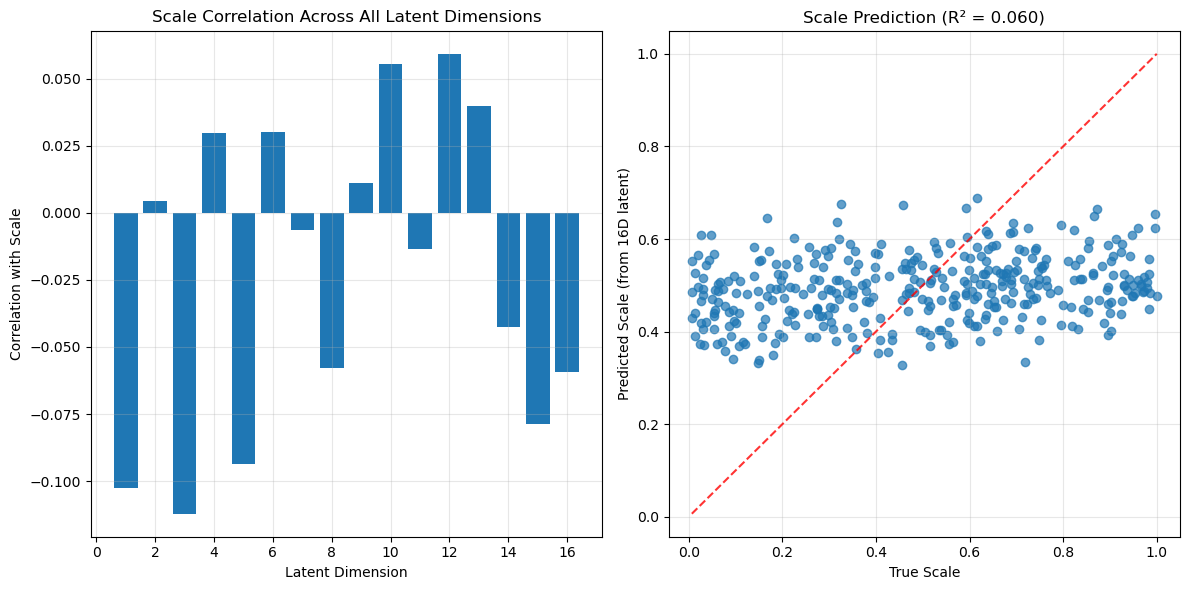

In [21]:
# Test if scale information is distributed across all dimensions
print("\nAnalyzing scale encoding across all 16 dimensions:")

# Calculate correlation of each individual latent dimension with scale
latent_scale_correlations = []
for dim in range(X.shape[1]):
    corr = np.corrcoef(X[:, dim], scales)[0, 1]
    latent_scale_correlations.append(corr)
    print(f"Latent dim {dim+1}: scale correlation = {corr:.4f}")

# Check if scale can be predicted using all 16 dimensions
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Train a linear model to predict scale from all 16 latent dimensions
lr = LinearRegression()
lr.fit(X, scales)
predicted_scales = lr.predict(X)
r2 = r2_score(scales, predicted_scales)

print(f"\nLinear regression R² for predicting scale from all 16 dimensions: {r2:.4f}")
print(f"This suggests scale information is {'well' if r2 > 0.7 else 'poorly'} encoded in the full latent space")

# Visualize the correlation pattern
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, 17), latent_scale_correlations)
plt.xlabel('Latent Dimension')
plt.ylabel('Correlation with Scale')
plt.title('Scale Correlation Across All Latent Dimensions')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(scales, predicted_scales, alpha=0.7)
plt.xlabel('True Scale')
plt.ylabel('Predicted Scale (from 16D latent)')
plt.title(f'Scale Prediction (R² = {r2:.3f})')
plt.plot([scales.min(), scales.max()], [scales.min(), scales.max()], 'r--', alpha=0.8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scale_analysis_full_latent_space.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Add this cell to your notebook
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import seaborn as sns

# Unsupervised Clustering Analysis
print("=== UNSUPERVISED CLUSTERING ANALYSIS ===")

# Use your original 16D latent vectors
X_clustering = X.copy()  # Your original 16D latent vectors

# Standardize the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Dictionary to store clustering results
clustering_results = {}
cluster_metrics = {}

# 1. K-Means Clustering with different numbers of clusters
print("\n1. K-Means Clustering:")
k_range = range(2, 11)  # Try 2 to 10 clusters
kmeans_scores = {'silhouette': [], 'calinski': [], 'davies_bouldin': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate clustering metrics
    sil_score = silhouette_score(X_scaled, cluster_labels)
    cal_score = calinski_harabasz_score(X_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_scaled, cluster_labels)
    
    kmeans_scores['silhouette'].append(sil_score)
    kmeans_scores['calinski'].append(cal_score)
    kmeans_scores['davies_bouldin'].append(db_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, Calinski-Harabasz={cal_score:.1f}, Davies-Bouldin={db_score:.3f}")
    
    if k == 3:  # Store 3-cluster result as example
        clustering_results['KMeans_3'] = cluster_labels
        cluster_metrics['KMeans_3'] = {'silhouette': sil_score, 'calinski': cal_score, 'davies_bouldin': db_score}

# Find optimal K for K-means
best_k_sil = k_range[np.argmax(kmeans_scores['silhouette'])]
best_k_cal = k_range[np.argmax(kmeans_scores['calinski'])]
best_k_db = k_range[np.argmin(kmeans_scores['davies_bouldin'])]

print(f"\nOptimal K by Silhouette: {best_k_sil}")
print(f"Optimal K by Calinski-Harabasz: {best_k_cal}")
print(f"Optimal K by Davies-Bouldin: {best_k_db}")

# Run K-means with the best K (by silhouette score)
best_kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
best_kmeans_labels = best_kmeans.fit_predict(X_scaled)
clustering_results['KMeans_Best'] = best_kmeans_labels

=== UNSUPERVISED CLUSTERING ANALYSIS ===

1. K-Means Clustering:
K=2: Silhouette=0.080, Calinski-Harabasz=32.0, Davies-Bouldin=3.342
K=3: Silhouette=0.076, Calinski-Harabasz=23.6, Davies-Bouldin=3.337
K=4: Silhouette=0.058, Calinski-Harabasz=20.7, Davies-Bouldin=3.507
K=5: Silhouette=0.060, Calinski-Harabasz=18.9, Davies-Bouldin=3.157
K=6: Silhouette=0.053, Calinski-Harabasz=17.4, Davies-Bouldin=3.022
K=7: Silhouette=0.051, Calinski-Harabasz=15.8, Davies-Bouldin=2.831
K=8: Silhouette=0.059, Calinski-Harabasz=15.0, Davies-Bouldin=2.768
K=9: Silhouette=0.050, Calinski-Harabasz=14.0, Davies-Bouldin=2.779
K=10: Silhouette=0.055, Calinski-Harabasz=13.6, Davies-Bouldin=2.673

Optimal K by Silhouette: 2
Optimal K by Calinski-Harabasz: 2
Optimal K by Davies-Bouldin: 10


In [15]:
# 2. Gaussian Mixture Model
print("\n2. Gaussian Mixture Model:")
gmm_scores = {'silhouette': [], 'aic': [], 'bic': []}

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = gmm.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    aic_score = gmm.aic(X_scaled)
    bic_score = gmm.bic(X_scaled)
    
    gmm_scores['silhouette'].append(sil_score)
    gmm_scores['aic'].append(aic_score)
    gmm_scores['bic'].append(bic_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}")

# Find optimal K for GMM
best_k_gmm = k_range[np.argmax(gmm_scores['silhouette'])]
best_gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
best_gmm_labels = best_gmm.fit_predict(X_scaled)
clustering_results['GMM_Best'] = best_gmm_labels

# 3. DBSCAN Clustering
print("\n3. DBSCAN Clustering:")
# Try different eps values
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    if n_clusters > 1:  # Only calculate if we have valid clusters
        sil_score = silhouette_score(X_scaled, cluster_labels)
        dbscan_results.append((eps, n_clusters, n_noise, sil_score))
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, Silhouette={sil_score:.3f}")
    else:
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points (invalid)")

# Select best DBSCAN result
if dbscan_results:
    best_dbscan = max(dbscan_results, key=lambda x: x[3])  # Best by silhouette score
    best_eps = best_dbscan[0]
    
    dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = dbscan_final.fit_predict(X_scaled)
    clustering_results['DBSCAN_Best'] = dbscan_labels
    print(f"Best DBSCAN: eps={best_eps}, silhouette={best_dbscan[3]:.3f}")


2. Gaussian Mixture Model:
K=2: Silhouette=0.081, AIC=16657.8, BIC=17850.6
K=3: Silhouette=0.076, AIC=16792.8, BIC=18583.9
K=4: Silhouette=0.048, AIC=16843.3, BIC=19232.8
K=5: Silhouette=0.036, AIC=16942.3, BIC=19930.2
K=6: Silhouette=0.045, AIC=17059.2, BIC=20645.4
K=7: Silhouette=0.041, AIC=17155.7, BIC=21340.3
K=8: Silhouette=0.042, AIC=17244.0, BIC=22026.9
K=9: Silhouette=0.047, AIC=17436.4, BIC=22817.6
K=10: Silhouette=0.045, AIC=17567.1, BIC=23546.7

3. DBSCAN Clustering:
eps=0.3: 0 clusters, 369 noise points (invalid)
eps=0.5: 0 clusters, 369 noise points (invalid)
eps=0.7: 0 clusters, 369 noise points (invalid)
eps=1.0: 0 clusters, 369 noise points (invalid)
eps=1.5: 0 clusters, 369 noise points (invalid)
eps=2.0: 0 clusters, 369 noise points (invalid)


In [16]:
# 4. Hierarchical Clustering
print("\n4. Hierarchical Clustering:")
hier_linkages = ['ward', 'complete', 'average']
hier_results = {}

for linkage in hier_linkages:
    for k in [3, 4, 5]:
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        cluster_labels = hierarchical.fit_predict(X_scaled)
        
        sil_score = silhouette_score(X_scaled, cluster_labels)
        hier_results[f'{linkage}_{k}'] = (cluster_labels, sil_score)
        print(f"Linkage={linkage}, K={k}: Silhouette={sil_score:.3f}")

# Find best hierarchical clustering
best_hier = max(hier_results.items(), key=lambda x: x[1][1])
clustering_results['Hierarchical_Best'] = best_hier[1][0]

# 5. Spectral Clustering
print("\n5. Spectral Clustering:")
spectral_results = {}

for k in [3, 4, 5]:
    spectral = SpectralClustering(n_clusters=k, random_state=42)
    cluster_labels = spectral.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    spectral_results[k] = (cluster_labels, sil_score)
    print(f"K={k}: Silhouette={sil_score:.3f}")

# Find best spectral clustering
best_spectral = max(spectral_results.items(), key=lambda x: x[1][1])
clustering_results['Spectral_Best'] = best_spectral[1][0]


4. Hierarchical Clustering:
Linkage=ward, K=3: Silhouette=0.023
Linkage=ward, K=4: Silhouette=0.026
Linkage=ward, K=5: Silhouette=0.022
Linkage=complete, K=3: Silhouette=0.017
Linkage=complete, K=4: Silhouette=0.017
Linkage=complete, K=5: Silhouette=0.019
Linkage=average, K=3: Silhouette=0.054
Linkage=average, K=4: Silhouette=0.032
Linkage=average, K=5: Silhouette=0.019

5. Spectral Clustering:
K=3: Silhouette=0.048
K=4: Silhouette=0.013
K=5: Silhouette=-0.003



6. Visualization of Clustering Results:


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Using UMAP for visualization


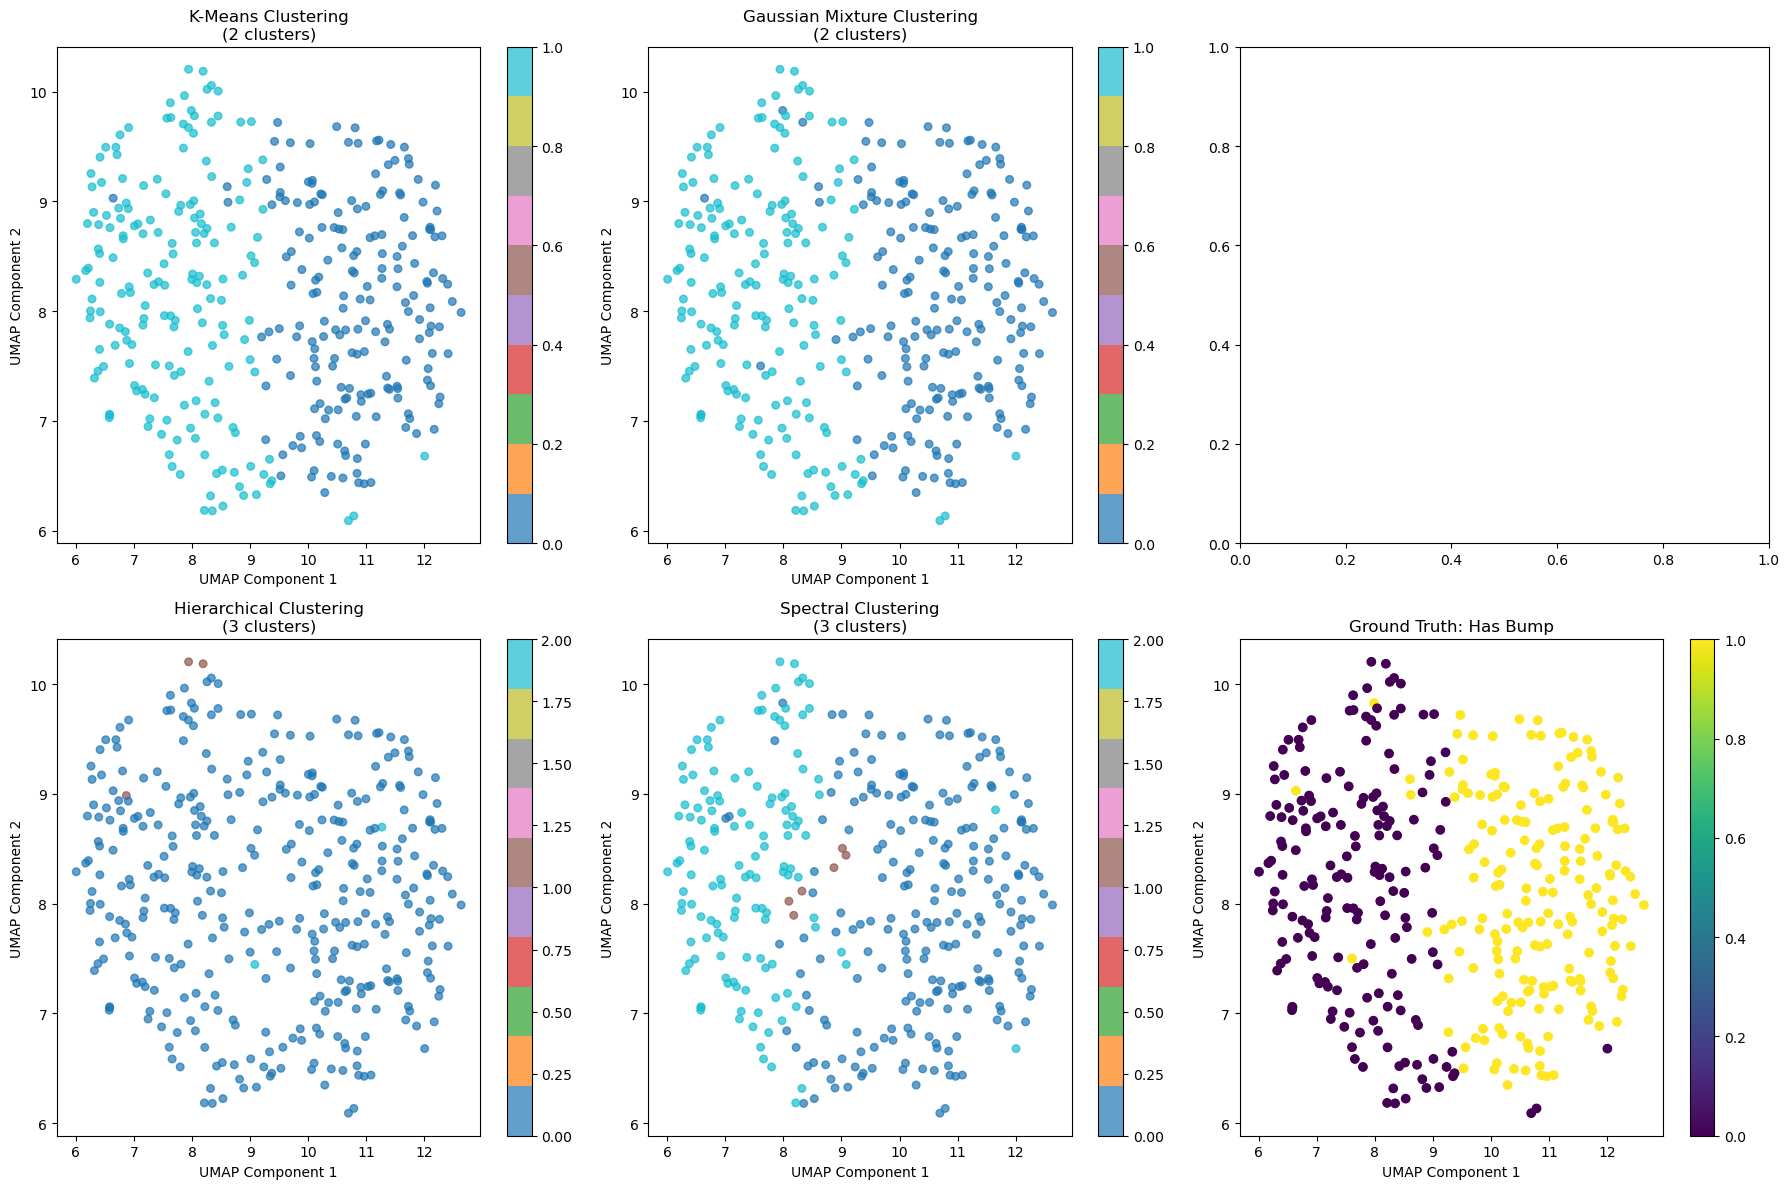

In [18]:
# 6. Visualize clustering results using dimensionality reduction
print("\n6. Visualization of Clustering Results:")

# Use UMAP for better visualization of clusters
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    print("Using UMAP for visualization")
except ImportError:
    # Fallback to t-SNE if UMAP is not available
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_umap = tsne.fit_transform(X_scaled)
    print("Using t-SNE for visualization")

# Plot clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

methods = ['KMeans_Best', 'GMM_Best', 'DBSCAN_Best', 'Hierarchical_Best', 'Spectral_Best']
method_names = ['K-Means', 'Gaussian Mixture', 'DBSCAN', 'Hierarchical', 'Spectral']

for i, (method, name) in enumerate(zip(methods, method_names)):
    if method in clustering_results:
        labels = clustering_results[method]
        scatter = axes[i].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, 
                                 cmap='tab10', alpha=0.7, s=30)
        axes[i].set_title(f'{name} Clustering\n({len(set(labels))} clusters)')
        axes[i].set_xlabel('UMAP Component 1')
        axes[i].set_ylabel('UMAP Component 2')
        plt.colorbar(scatter, ax=axes[i])

# Compare with your known labels
axes[5].scatter(X_umap[:, 0], X_umap[:, 1], c=has_bump, cmap='viridis', alpha=0.7, s=30)
axes[5].set_title('Ground Truth: Has Bump')
axes[5].set_xlabel('UMAP Component 1')
axes[5].set_ylabel('UMAP Component 2')
plt.colorbar(axes[5].scatter(X_umap[:, 0], X_umap[:, 1], c=has_bump, cmap='viridis'), ax=axes[5])

plt.tight_layout()
plt.savefig("clustering_results_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 7. Analyze cluster characteristics
print("\n7. Cluster Analysis:")

# Analyze the best K-means clustering
best_labels = clustering_results['KMeans_Best']
unique_clusters = sorted(set(best_labels))

print(f"\nAnalyzing K-Means clustering with {len(unique_clusters)} clusters:")

cluster_analysis = {}
for cluster_id in unique_clusters:
    cluster_mask = best_labels == cluster_id
    
    # Analyze cluster characteristics
    cluster_bump_ratio = np.mean(has_bump[cluster_mask])
    cluster_scale_mean = np.mean(scales[cluster_mask])
    cluster_scale_std = np.std(scales[cluster_mask])
    cluster_size = np.sum(cluster_mask)
    
    cluster_analysis[cluster_id] = {
        'size': cluster_size,
        'bump_ratio': cluster_bump_ratio,
        'scale_mean': cluster_scale_mean,
        'scale_std': cluster_scale_std
    }
    
    print(f"Cluster {cluster_id}:")
    print(f"  Size: {cluster_size} samples")
    print(f"  Bump ratio: {cluster_bump_ratio:.3f}")
    print(f"  Scale mean±std: {cluster_scale_mean:.3f}±{cluster_scale_std:.3f}")

# 8. Create new labels from clustering
print("\n8. Creating Training Labels from Clusters:")

# You can use these cluster labels as new training targets
cluster_labels_for_training = best_labels

# Save the cluster assignments
np.save("unsupervised_cluster_labels.npy", cluster_labels_for_training)
print(f"Saved cluster labels to 'unsupervised_cluster_labels.npy'")
print(f"Shape: {cluster_labels_for_training.shape}")
print(f"Unique clusters: {sorted(set(cluster_labels_for_training))}")

# You can now use cluster_labels_for_training as your new training targets
# for any supervised learning task


7. Cluster Analysis:

Analyzing K-Means clustering with 2 clusters:
Cluster 0:
  Size: 190 samples
  Bump ratio: 1.000
  Scale mean±std: 0.493±0.280
Cluster 1:
  Size: 179 samples
  Bump ratio: 0.017
  Scale mean±std: 0.492±0.297

8. Creating Training Labels from Clusters:
Saved cluster labels to 'unsupervised_cluster_labels.npy'
Shape: (369,)
Unique clusters: [0, 1]
